# Credit Risk Business Case - Danna Vilchis
## 1. Data Overview

Queremos estimar el riesgo de impago del siguiente mes a partir del comportamiento reciente del cliente. Primero conocemos la cartera, comparamos los dos grupos del objetivo y construimos indicadores de atraso. Después desarrollamos variables comportamentales, reservamos una muestra de prueba, seleccionamos variables únicamente con entrenamiento y comparamos tres modelos con sus calibraciones.

Cada fila contiene un cliente y seis meses de historia, de abril a septiembre de 2005. `Y = 1` indica el evento del mes siguiente; `Y = 0`, su ausencia. En las tablas se conserva la nomenclatura `X1`–`X23` del archivo original. Las gráficas mensuales se leen de **abril a septiembre**.

La muestra de test se mantiene fuera de la selección de variables y del entrenamiento para evitar leakage y obtener una evaluación más defendible.


In [1]:
# Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.ticker import PercentFormatter, StrMethodFormatter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    average_precision_score,
    brier_score_loss,
    log_loss
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

from ucimlrepo import fetch_ucirepo

MONTH_BY_COLUMN = {
    "X6": "Septiembre",
    "X7": "Agosto",
    "X8": "Julio",
    "X9": "Junio",
    "X10": "Mayo",
    "X11": "Abril"
}

MONTHS_ES = ["Abril", "Mayo", "Junio", "Julio", "Agosto", "Septiembre"]

MONTH_EN = {
    "Abril": "April",
    "Mayo": "May",
    "Junio": "June",
    "Julio": "July",
    "Agosto": "August",
    "Septiembre": "September"
}


In [2]:
# cargar dataset
default_of_credit_card_clients = fetch_ucirepo(id=350) 
  
# data (as pandas dataframes) 
X = default_of_credit_card_clients.data.features 
y = default_of_credit_card_clients.data.targets 
  
# metadata 
print(default_of_credit_card_clients.metadata) 
  
# variable information 
print(default_of_credit_card_clients.variables) 


{'uci_id': 350, 'name': 'Default of Credit Card Clients', 'repository_url': 'https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients', 'data_url': 'https://archive.ics.uci.edu/static/public/350/data.csv', 'abstract': "This research aimed at the case of customers' default payments in Taiwan and compares the predictive accuracy of probability of default among six data mining methods.", 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 30000, 'num_features': 23, 'feature_types': ['Integer', 'Real'], 'demographics': ['Sex', 'Education Level', 'Marital Status', 'Age'], 'target_col': ['Y'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Fri Mar 29 2024', 'dataset_doi': '10.24432/C55S3H', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 365, 'type': 'NATIVE', 'title': 'The comparisons of data mining techniques for the predictive accuracy of 

In [3]:
datos = pd.concat([X, y], axis=1)
datos.head()


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [4]:
print("Filas:", datos.shape[0])
print("Columnas:", datos.shape[1])


Filas: 30000
Columnas: 24


### Data Quality

Revisamos faltantes y filas repetidas antes de interpretar los resultados. Este recorrido conserva las observaciones: no aplica imputación ni elimina duplicados.

In [5]:
datos.isnull().sum()


X1     0
X2     0
X3     0
X4     0
X5     0
X6     0
X7     0
X8     0
X9     0
X10    0
X11    0
X12    0
X13    0
X14    0
X15    0
X16    0
X17    0
X18    0
X19    0
X20    0
X21    0
X22    0
X23    0
Y      0
dtype: int64

In [6]:
datos.duplicated().sum()


np.int64(35)

### Target Distribution

La proporción de `Y = 1` es nuestra referencia inicial. Los nombres *Default* y *No Default* se refieren a la etiqueta futura, no a una certificación del estado actual del cliente.

In [7]:
target = y.columns[0]

datos[target].value_counts()


Y
0    23364
1     6636
Name: count, dtype: int64

In [8]:
datos[target].value_counts(normalize=True) * 100


Y
0    77.88
1    22.12
Name: proportion, dtype: float64

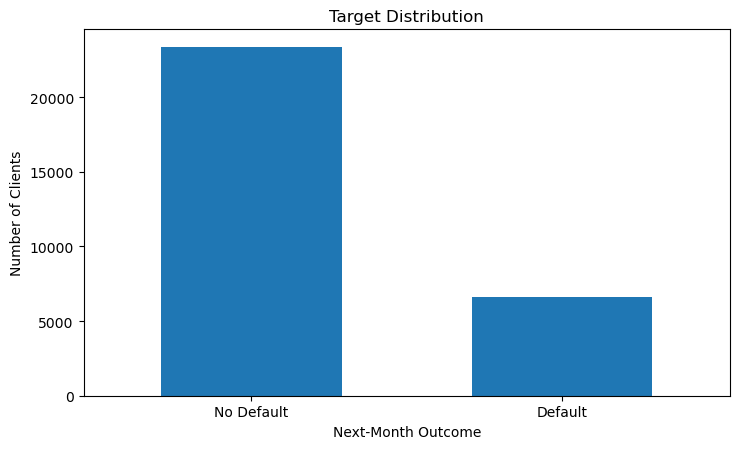

In [9]:
datos[target].value_counts().sort_index().plot(
    kind="bar",
    figsize=(7.5, 4.6),
    width=0.58
)

plt.xticks([0, 1], ["No Default", "Default"], rotation=0)

plt.title("Target Distribution")
plt.xlabel("Next-Month Outcome")
plt.ylabel("Number of Clients")
plt.tight_layout()
plt.show()


### Customer Profile

Empezamos por el límite de crédito (`X1`): cuánto suele otorgarse y qué tan dispersos son los importes.

In [10]:
datos.columns


Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11',
       'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21',
       'X22', 'X23', 'Y'],
      dtype='object')

In [11]:
datos["X1"].describe()


count      30000.000000
mean      167484.322667
std       129747.661567
min        10000.000000
25%        50000.000000
50%       140000.000000
75%       240000.000000
max      1000000.000000
Name: X1, dtype: float64

In [12]:
datos["X1"].describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]
)


count      30000.000000
mean      167484.322667
std       129747.661567
min        10000.000000
10%        30000.000000
25%        50000.000000
50%       140000.000000
75%       240000.000000
90%       360000.000000
max      1000000.000000
Name: X1, dtype: float64

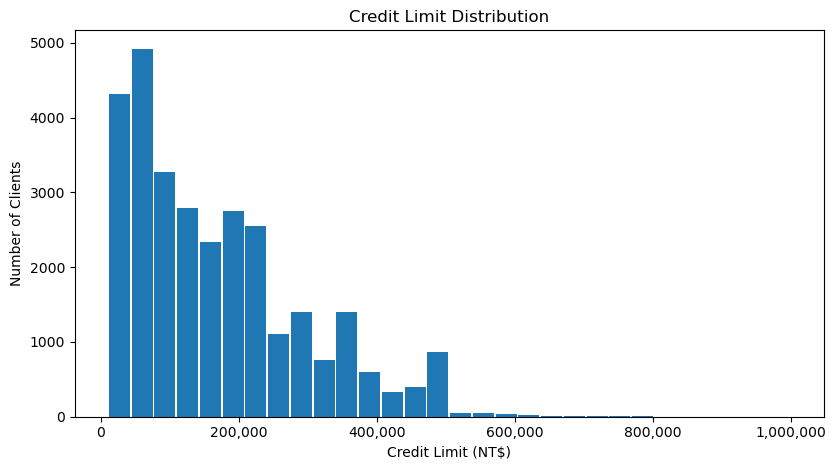

In [13]:
plt.figure(figsize=(8.5, 4.8))

plt.hist(
    datos["X1"].dropna(),
    bins=30,
    rwidth=0.92
)

plt.gca().xaxis.set_major_formatter(
    StrMethodFormatter("{x:,.0f}")
)

plt.title("Credit Limit Distribution")
plt.xlabel("Credit Limit (NT$)")
plt.ylabel("Number of Clients")
plt.tight_layout()
plt.show()


La media supera a la mediana: unos límites altos desplazan el promedio. La distribución describe la cartera; por sí sola no demuestra que esos valores sean errores. El caso conserva los importes sin recortarlos.

### Age

La edad (`X5`) completa el perfil básico. Revisamos su rango y dónde se concentra la población.

In [14]:
datos["X5"].describe()


count    30000.000000
mean        35.485500
std          9.217904
min         21.000000
25%         28.000000
50%         34.000000
75%         41.000000
max         79.000000
Name: X5, dtype: float64

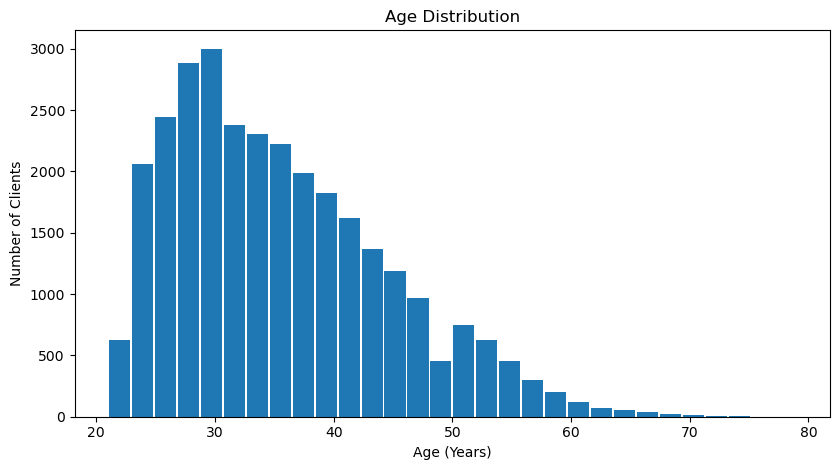

In [15]:
plt.figure(figsize=(8.5, 4.8))

plt.hist(
    datos["X5"].dropna(),
    bins=30,
    rwidth=0.92
)

plt.title("Age Distribution")
plt.xlabel("Age (Years)")
plt.ylabel("Number of Clients")
plt.tight_layout()
plt.show()


### Demographic Variables

Las frecuencias de sexo, educación y estado civil permiten reconocer categorías frecuentes y poco representadas. Se mantienen los códigos del archivo.

In [16]:
categoricas = ["X2", "X3", "X4"]

for variable in categoricas:
    
    resumen = pd.DataFrame({
        "Clientes": datos[variable].value_counts().sort_index(),
        "Porcentaje": (
            datos[variable]
            .value_counts(normalize=True)
            .sort_index() * 100
        ).round(2)
    })
    
    print(f"\n{variable}")
    display(resumen)



X2


,Clientes,Porcentaje
X2,,
1,11888,39.63
2,18112,60.37



X3


,Clientes,Porcentaje
X3,,
0,14,0.05
1,10585,35.28
2,14030,46.77
3,4917,16.39
4,123,0.41
5,280,0.93
6,51,0.17



X4


,Clientes,Porcentaje
X4,,
0,54,0.18
1,13659,45.53
2,15964,53.21
3,323,1.08


### Monthly Payment Status

`X6` corresponde a septiembre y `X11` a abril. Cada valor describe el estado de pago en ese corte. Las siguientes distribuciones se presentan en orden cronológico, sin cambiar el orden de las variables en los cálculos.

In [17]:
pay_cols = [
    "X6", "X7", "X8",
    "X9", "X10", "X11"
]


In [18]:
for variable in pay_cols:
    print(f"\n{variable}")
    print(datos[variable].value_counts().sort_index())



X6
X6
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

X7
X7
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

X8
X8
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

X9
X9
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

X10
X10
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64

X11
X11
-2     4895
-1     5740
 0    16286
 2     2766
 3      184
 4       49
 5       13
 6       19
 7       46
 8        2
Name: count, dtype: int64


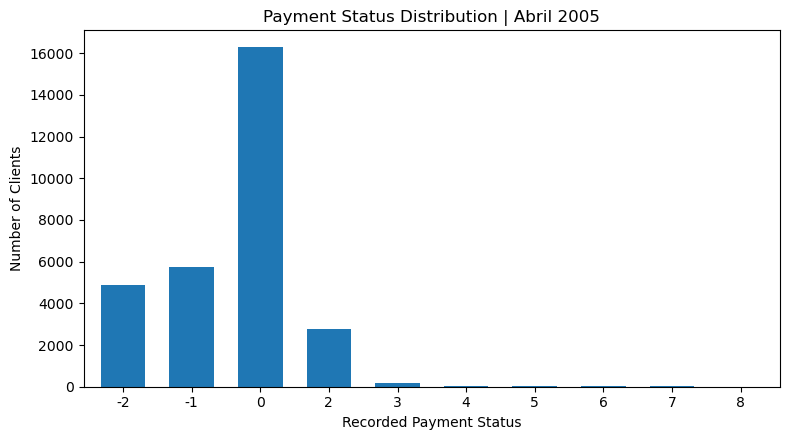

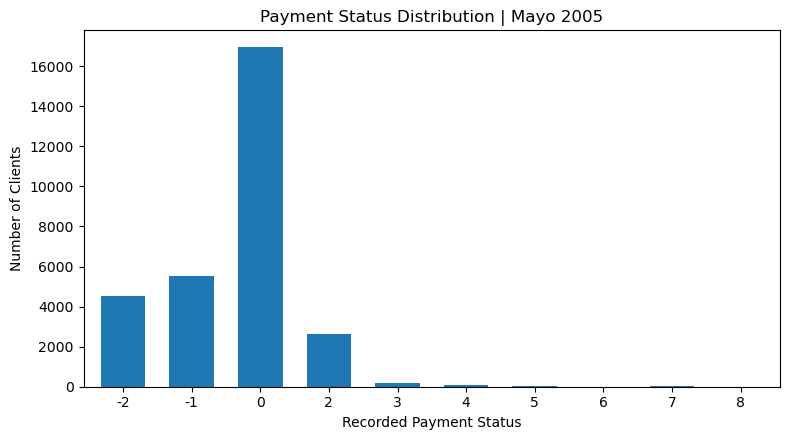

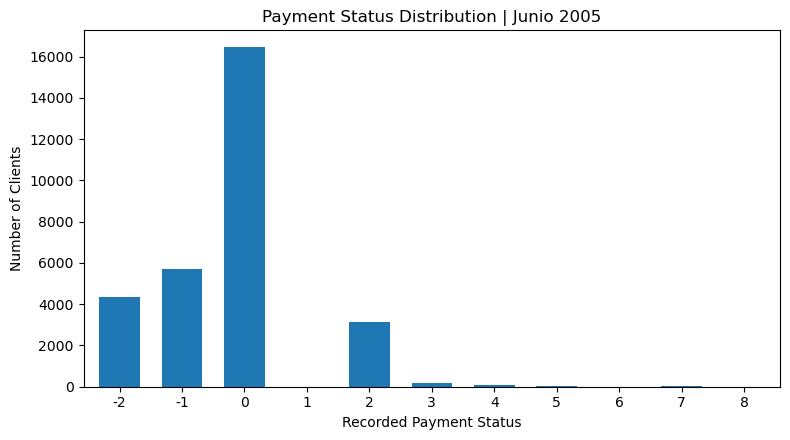

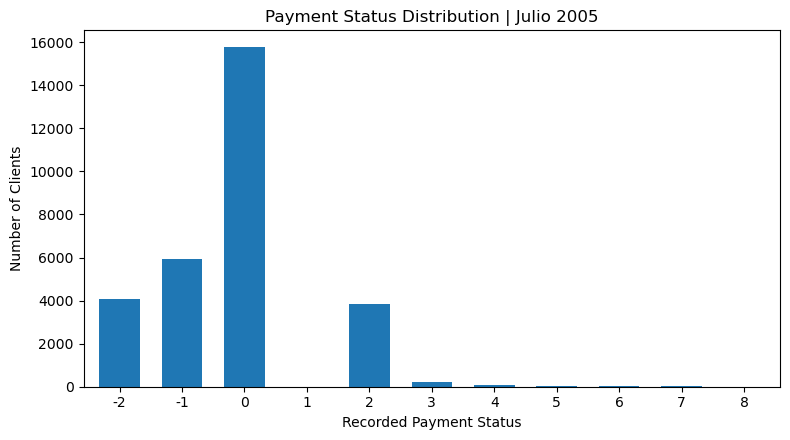

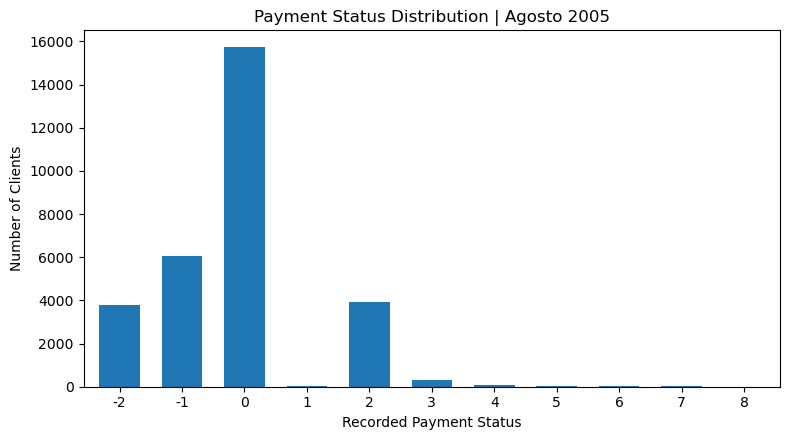

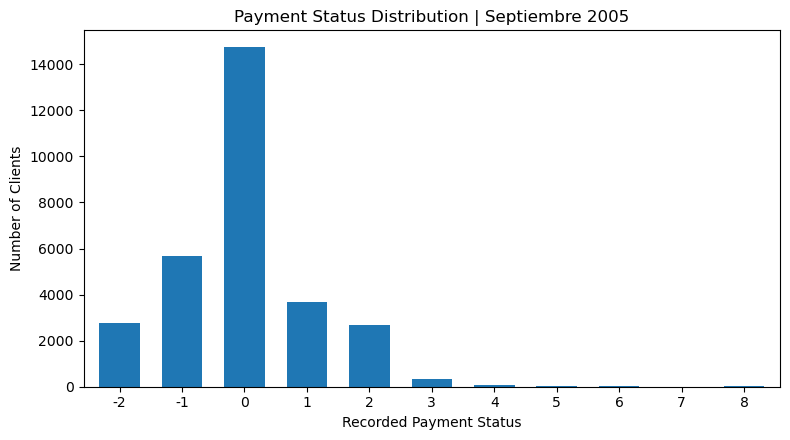

In [19]:
# Orden de presentación: abril → septiembre
for variable in reversed(pay_cols):

    counts_for_plot = (
        datos[variable]
        .value_counts()
        .sort_index()
    )

    plt.figure(figsize=(8.0, 4.5))

    counts_for_plot.plot(
        kind="bar",
        width=0.65
    )

    plt.xticks(rotation=0)

    plt.title(
        f"Payment Status Distribution | "
        f"{MONTH_BY_COLUMN[variable]} 2005"
    )
    plt.xlabel("Recorded Payment Status")
    plt.ylabel("Number of Clients")
    plt.tight_layout()
    plt.show()


### Statement Balances

Los saldos facturados son `X12`–`X17`. Comparamos media, mediana y extremos para reconocer la escala de cada mes.

In [20]:
bill_cols = [
    "X12", "X13", "X14",
    "X15", "X16", "X17"
]

datos[bill_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
X12,30000.0,51223.330900,73635.860576,-165580.0,3558.75,22381.5,67091.00,964511.0
X13,30000.0,49179.075167,71173.768783,-69777.0,2984.75,21200.0,64006.25,983931.0
X14,30000.0,47013.154800,69349.387427,-157264.0,2666.25,20088.5,60164.75,1664089.0
X15,30000.0,43262.948967,64332.856134,-170000.0,2326.75,19052.0,54506.00,891586.0
X16,30000.0,40311.400967,60797.155770,-81334.0,1763.00,18104.5,50190.50,927171.0
X17,30000.0,38871.760400,59554.107537,-339603.0,1256.00,17071.0,49198.25,961664.0


### Payment Amounts

Los pagos registrados son `X18`–`X23`. El resumen mensual reúne saldos y pagos; todavía no supone que cada pago liquide exactamente el saldo del mismo mes.

In [21]:
payment_cols = [
    "X18", "X19", "X20",
    "X21", "X22", "X23"
]

datos[payment_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
X18,30000.0,5663.580500,16563.280354,0.0,1000.00,2100.0,5006.00,873552.0
X19,30000.0,5921.163500,23040.870402,0.0,833.00,2009.0,5000.00,1684259.0
X20,30000.0,5225.681500,17606.961470,0.0,390.00,1800.0,4505.00,896040.0
X21,30000.0,4826.076867,15666.159744,0.0,296.00,1500.0,4013.25,621000.0
X22,30000.0,4799.387633,15278.305679,0.0,252.50,1500.0,4031.50,426529.0
X23,30000.0,5215.502567,17777.465775,0.0,117.75,1500.0,4000.00,528666.0


In [22]:
resumen_mensual = pd.DataFrame({
    "Mes": [
        "Septiembre", "Agosto", "Julio",
        "Junio", "Mayo", "Abril"
    ],
    "Bill promedio": datos[bill_cols].mean().values,
    "Bill mediano": datos[bill_cols].median().values,
    "Pago promedio": datos[payment_cols].mean().values,
    "Pago mediano": datos[payment_cols].median().values
})

resumen_mensual.round(2)


,Mes,Bill promedio,Bill mediano,Pago promedio,Pago mediano
0,Septiembre,51223.33,22381.5,5663.58,2100.0
1,Agosto,49179.08,21200.0,5921.16,2009.0
2,Julio,47013.15,20088.5,5225.68,1800.0
3,Junio,43262.95,19052.0,4826.08,1500.0
4,Mayo,40311.40,18104.5,4799.39,1500.0
5,Abril,38871.76,17071.0,5215.50,1500.0


## 2. Default vs. Non-Default

Ahora comparamos los perfiles según `Y`. Buscamos diferencias que puedan aportar señal al modelo, sin interpretar una asociación como una relación causal.

In [23]:
datos = pd.concat([X, y], axis=1)


In [24]:
# Separar clientes según default

no_default = datos[datos["Y"] == 0]
default = datos[datos["Y"] == 1]

print("Clientes sin default:", len(no_default))
print("Clientes con default:", len(default))

print("\nPorcentaje:")
print(datos["Y"].value_counts(normalize=True) * 100)


Clientes sin default: 23364
Clientes con default: 6636

Porcentaje:
Y
0    77.88
1    22.12
Name: proportion, dtype: float64


### Credit Limit

¿Los clientes que presentan el evento tienen límites distintos de quienes no lo presentan? Revisamos tanto el promedio como la mediana.

In [25]:
datos.groupby("Y")["X1"].agg([
    "count",
    "mean",
    "median",
    "std",
    "min",
    "max"
]).round(2)


,count,mean,median,std,min,max
Y,,,,,,
0,23364,178099.73,150000.0,131628.36,10000,1000000
1,6636,130109.66,90000.0,115378.54,10000,740000


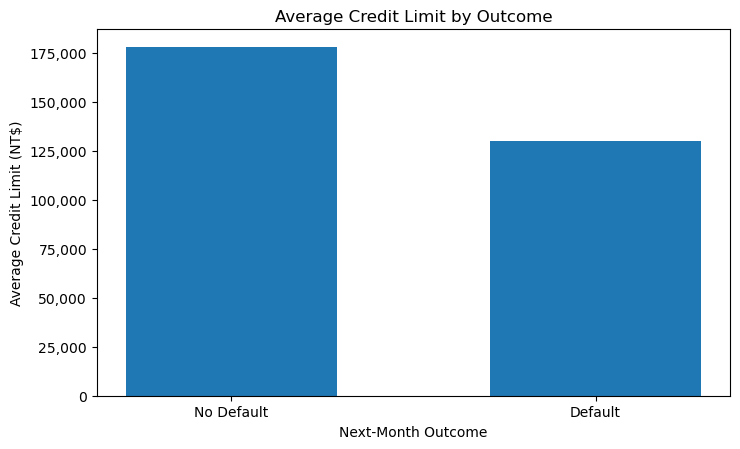

In [26]:
promedios = datos.groupby("Y")["X1"].mean()

plt.figure(figsize=(7.5, 4.6))

plt.bar(
    ["No Default", "Default"],
    promedios.reindex([0, 1]).values,
    width=0.58
)

plt.gca().yaxis.set_major_formatter(
    StrMethodFormatter("{x:,.0f}")
)

plt.title("Average Credit Limit by Outcome")
plt.xlabel("Next-Month Outcome")
plt.ylabel("Average Credit Limit (NT$)")
plt.tight_layout()
plt.show()


El grupo con evento tiene un límite promedio menor. Esto ayuda a describir los perfiles; no significa que aumentar el límite de un cliente reduzca su riesgo.

### Payment History

Primero comparamos los códigos promedio y después la proporción de clientes con códigos positivos. La segunda lectura hace más clara la diferencia entre grupos.

In [27]:
variables_historial = [
    "X6", "X7", "X8",
    "X9", "X10", "X11"
]

historial = datos.groupby("Y")[variables_historial].mean().T

historial.columns = ["No Default", "Default"]

historial


,No Default,Default
X6,-0.211222,0.668174
X7,-0.301917,0.458258
X8,-0.316256,0.362116
X9,-0.355633,0.254521
X10,-0.389488,0.167872
X11,-0.405624,0.112116


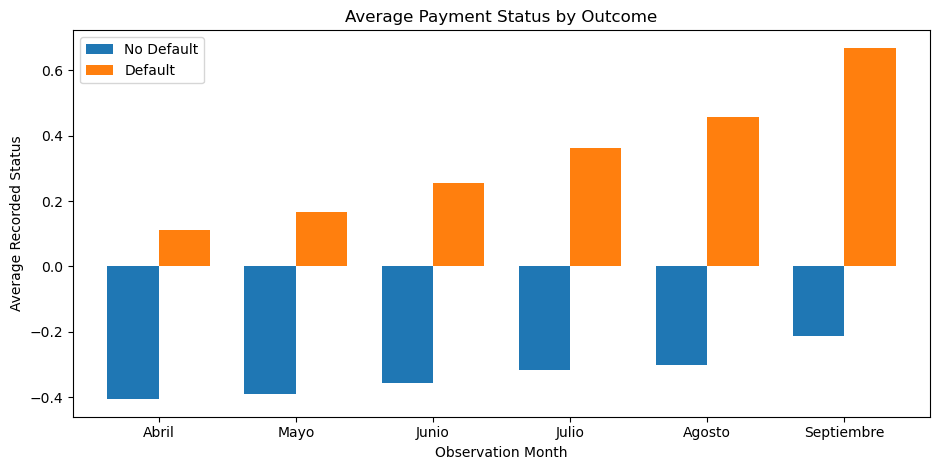

In [28]:
historial.reindex(
    list(reversed(variables_historial))
).rename(
    index=MONTH_BY_COLUMN
).plot(
    kind="bar",
    figsize=(9.5, 4.8),
    width=0.75
)

plt.xticks(rotation=0)
plt.title("Average Payment Status by Outcome")
plt.xlabel("Observation Month")
plt.ylabel("Average Recorded Status")
plt.tight_layout()
plt.show()


Aquí el atraso mensual se identifica con `PAY > 0`, tal como en el código original.

In [29]:
tasas_atraso = []

for variable in variables_historial:

    tabla = datos.groupby("Y")[variable].apply(
        lambda x: (x > 0).mean() * 100
    )

    tasas_atraso.append({
        "Variable": variable,
        "No Default": tabla[0],
        "Default": tabla[1]
    })

tasas_atraso = pd.DataFrame(tasas_atraso)

tasas_atraso


,Variable,No Default,Default
0,X6,14.505222,51.672694
1,X7,8.397535,37.311634
2,X8,8.607259,33.182640
3,X9,6.980825,28.315250
4,X10,5.645437,24.849307
5,X11,6.283171,24.276673


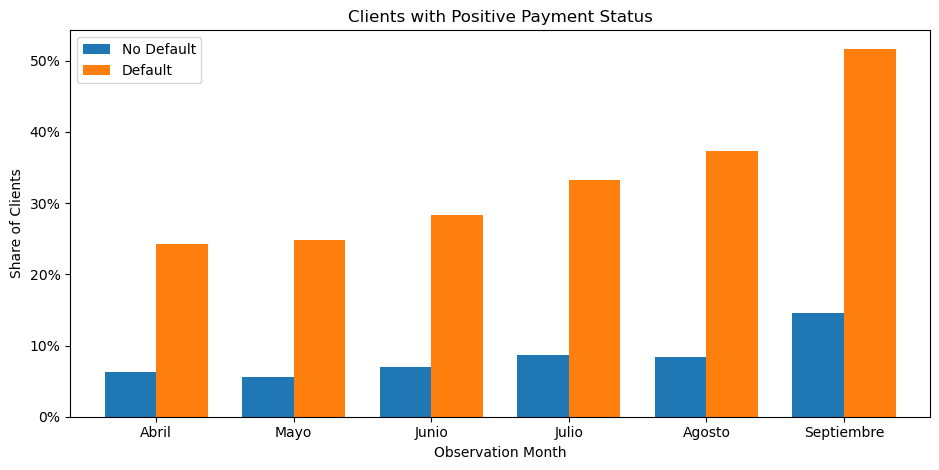

In [30]:
tasas_atraso.set_index("Variable").reindex(
    list(reversed(variables_historial))
).rename(
    index=MONTH_BY_COLUMN
).plot(
    kind="bar",
    figsize=(9.5, 4.8),
    width=0.75
)

plt.xticks(rotation=0)

# Las tasas ya están expresadas en escala 0–100
plt.gca().yaxis.set_major_formatter(
    PercentFormatter(xmax=100)
)

plt.title("Clients with Positive Payment Status")
plt.xlabel("Observation Month")
plt.ylabel("Share of Clients")
plt.tight_layout()
plt.show()


La diferencia en las frecuencias de atraso aporta una señal comportamental que retomaremos en los modelos.

### Number of Months with Delinquency

Contamos en cuántos cortes aparece un código positivo. No es lo mismo tener tres cortes con atraso que registrar un valor `PAY = 3` en un corte.

In [31]:
datos["meses_atraso"] = (
    datos[variables_historial] > 0
).sum(axis=1)


In [32]:
datos.groupby("Y")["meses_atraso"].agg([
    "mean",
    "median",
    "std"
]).round(2)


,mean,median,std
Y,,,
0,0.5,0.0,1.15
1,2.0,1.0,2.13


In [33]:
tabla_atrasos = pd.crosstab(
    datos["meses_atraso"],
    datos["Y"],
    normalize="columns"
) * 100

tabla_atrasos.columns = ["No Default", "Default"]
tabla_atrasos


,No Default,Default
meses_atraso,,
0,75.316727,35.171790
1,13.293957,19.891501
2,4.977744,11.091019
3,2.426810,8.845690
4,1.737716,8.212779
5,0.543571,2.576854
6,1.703475,14.210368


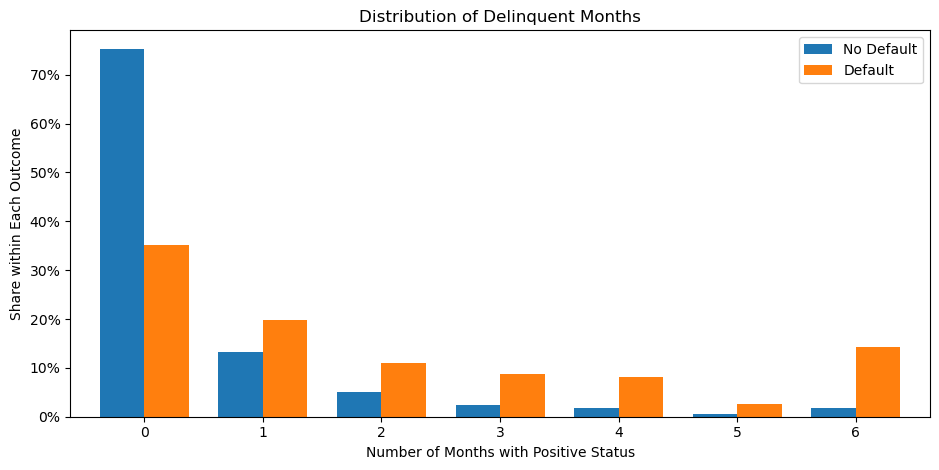

In [34]:
tabla_atrasos.plot(
    kind="bar",
    figsize=(9.5, 4.8),
    width=0.75
)

plt.xticks(rotation=0)

# La tabla ya está expresada en escala 0–100
plt.gca().yaxis.set_major_formatter(
    PercentFormatter(xmax=100)
)

plt.title("Distribution of Delinquent Months")
plt.xlabel("Number of Months with Positive Status")
plt.ylabel("Share within Each Outcome")
plt.tight_layout()
plt.show()


Las columnas de esta tabla suman 100% por grupo: muestran cómo se distribuyen los clientes con y sin evento según su número de meses con atraso.

### Statement Balances by Outcome

Comparamos la trayectoria de los saldos promedio de abril a septiembre. Un saldo absoluto no tiene la misma lectura para todos los límites de crédito.

In [35]:
variables_bill = [
    "X12", "X13", "X14",
    "X15", "X16", "X17"
]

bill_comparacion = datos.groupby("Y")[variables_bill].mean().T

bill_comparacion.columns = ["No Default", "Default"]

bill_comparacion


,No Default,Default
X12,51994.227273,48509.162297
X13,49717.435670,47283.617842
X14,47533.365605,45181.598855
X15,43611.165254,42036.950573
X16,40530.445343,39540.190476
X17,39042.268704,38271.435503


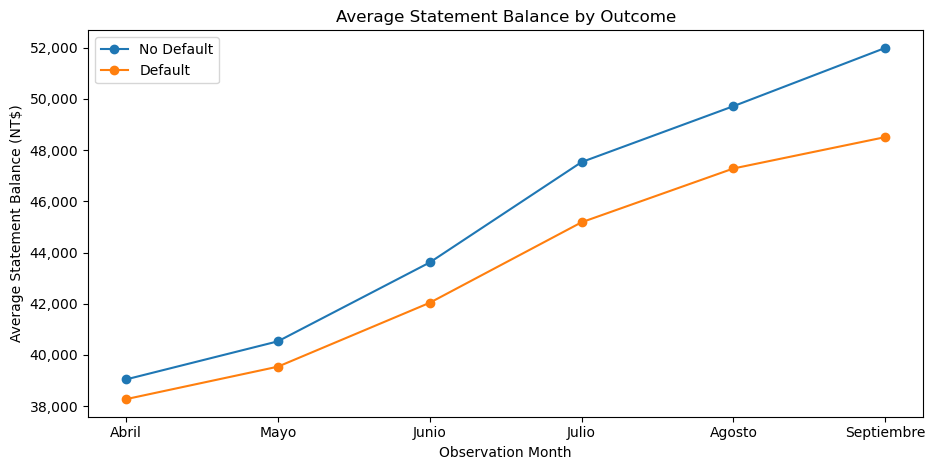

In [36]:
variables_bill = ["X12", "X13", "X14", "X15", "X16", "X17"]

MONTH_BY_COLUMN.update({
    "X12": "Septiembre",
    "X13": "Agosto",
    "X14": "Julio",
    "X15": "Junio",
    "X16": "Mayo",
    "X17": "Abril"
})
bill_comparacion.reindex(
    list(reversed(variables_bill))
).rename(
    index=MONTH_BY_COLUMN
).plot(
    kind="line",
    marker="o",
    figsize=(9.5, 4.8)
)

plt.gca().yaxis.set_major_formatter(
    StrMethodFormatter("{x:,.0f}")
)

plt.title("Average Statement Balance by Outcome")
plt.xlabel("Observation Month")
plt.ylabel("Average Statement Balance (NT$)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Payment Amounts by Outcome

La trayectoria de pagos complementa la de saldos. Permite comparar cuánto paga cada grupo en cada corte.

In [37]:
variables_pago = [
    "X18", "X19", "X20",
    "X21", "X22", "X23"
]

pagos_comparacion = datos.groupby("Y")[variables_pago].mean().T

pagos_comparacion.columns = ["No Default", "Default"]

pagos_comparacion


,No Default,Default
X18,6307.337357,3397.044153
X19,6640.465074,3388.649638
X20,5753.496833,3367.351567
X21,5300.529319,3155.626733
X22,5248.220296,3219.139542
X23,5719.371769,3441.482068


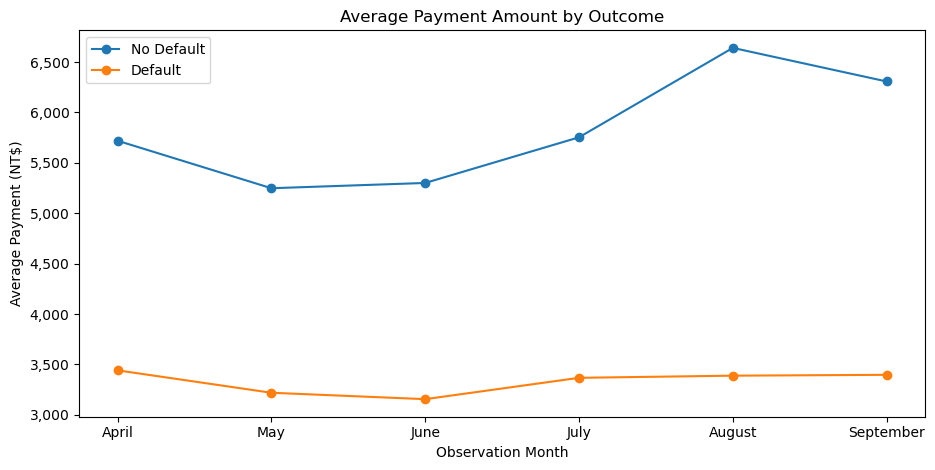

In [39]:
variables_pago = ["X18", "X19", "X20", "X21", "X22", "X23"]

MONTH_BY_COLUMN.update({
    "X18": "September",
    "X19": "August",
    "X20": "July",
    "X21": "June",
    "X22": "May",
    "X23": "April"
})

pagos_comparacion.reindex(
    list(reversed(variables_pago))
).rename(
    index=MONTH_BY_COLUMN
).plot(
    kind="line",
    marker="o",
    figsize=(9.5, 4.8)
)

plt.gca().yaxis.set_major_formatter(
    StrMethodFormatter("{x:,.0f}")
)

plt.title("Average Payment Amount by Outcome")
plt.xlabel("Observation Month")
plt.ylabel("Average Payment (NT$)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


El gráfico resume niveles promedio. Para hablar de irregularidad individual necesitaríamos medirla cliente por cliente; no basta con la forma de estas dos líneas.

### Relative Credit Use

Un saldo de 50,000 representa algo distinto sobre un límite de 60,000 que sobre uno de 300,000. Por eso el código calcula:

$$\text{Utilización} = \frac{\text{Saldo facturado}}{\text{Límite de crédito}}.$$



In [40]:
# Utilización mensual sobre la cartera completa
bills_util = ["X12", "X13", "X14", "X15", "X16", "X17"]
meses_util = ["Sep", "Ago", "Jul", "Jun", "May", "Abr"]

for bill_col, mes in zip(bills_util, meses_util):
    datos[f"utilizacion_{mes}"] = datos[bill_col] / datos["X1"]

datos.groupby("Y")["utilizacion_Sep"].agg([
    "mean",
    "median"
])


,mean,median
Y,,
0,0.404876,0.267498
1,0.490297,0.492875


La media y la mediana permiten comparar la utilización de septiembre entre los dos grupos.

## 3. Delinquency Patterns

Pasamos de observar cada mes por separado a resumir la trayectoria del cliente. Se conserva la regla del caso: un código positivo se convierte en 1 y un código no positivo en 0.

In [41]:
# Orden cronológico: abril -> septiembre

meses = {
    "X11": "Abril",
    "X10": "Mayo",
    "X9": "Junio",
    "X8": "Julio",
    "X7": "Agosto",
    "X6": "Septiembre"
}

variables_pago = list(meses.keys())


In [42]:
for var, mes in meses.items():
    datos[f"atraso_{mes}"] = (datos[var] > 0).astype(int)

cols_atraso = [f"atraso_{mes}" for mes in meses.values()]


### Total Delinquent Months

La suma de los seis indicadores cuenta meses con atraso, sean consecutivos o no.

In [43]:
tabla_meses = pd.crosstab(
    datos["meses_atraso"],
    datos["Y"]
)

tabla_meses.columns = ["No Default", "Default"]
tabla_meses["Total"] = tabla_meses["No Default"] + tabla_meses["Default"]
tabla_meses


,No Default,Default,Total
meses_atraso,,,
0,17597,2334,19931
1,3106,1320,4426
2,1163,736,1899
3,567,587,1154
4,406,545,951
5,127,171,298
6,398,943,1341


In [44]:
tabla_meses_pct = pd.crosstab(
    datos["meses_atraso"],
    datos["Y"],
    normalize="columns"
) * 100

tabla_meses_pct.columns = ["No Default", "Default"]

tabla_meses_pct.round(2)


,No Default,Default
meses_atraso,,
0,75.32,35.17
1,13.29,19.89
2,4.98,11.09
3,2.43,8.85
4,1.74,8.21
5,0.54,2.58
6,1.70,14.21


### Timing and Persistence

Una cadena como `001100` representa los seis cortes de abril a septiembre. Las tablas muestran los patrones más frecuentes y la racha más larga de cortes consecutivos con código positivo.

In [45]:
datos["patron_atraso"] = (
    datos[cols_atraso]
    .astype(str)
    .agg("".join, axis=1)
)

datos[["patron_atraso", "Y"]].head()


,patron_atraso,Y
0,000011,1
1,100010,1
2,000000,0
3,000000,0
4,000000,0


In [46]:
patrones = pd.crosstab(
    datos["patron_atraso"],
    datos["Y"]
)

patrones.columns = ["No Default", "Default"]

patrones["Total"] = patrones.sum(axis=1)

patrones = patrones.sort_values(
    "Total",
    ascending=False
)

patrones.head(15)


,No Default,Default,Total
patron_atraso,,,
000000,17597,2334,19931
000001,1515,854,2369
111111,398,943,1341
000011,565,391,956
000100,496,154,650
000111,237,305,542
100000,418,96,514
001111,204,260,464
001000,347,97,444


In [47]:
def meses_incumplidos(fila):
    
    incumplidos = []
    
    for col, mes in zip(cols_atraso, meses.values()):
        if fila[col] == 1:
            incumplidos.append(mes)
    
    if len(incumplidos) == 0:
        return "Ninguno"
    
    return ", ".join(incumplidos)


datos["meses_incumplidos"] = datos.apply(
    meses_incumplidos,
    axis=1
)


In [48]:
tabla_patrones = (
    datos.groupby(
        ["meses_incumplidos", "Y"]
    )
    .size()
    .unstack(fill_value=0)
)

tabla_patrones.columns = ["No Default", "Default"]

tabla_patrones["Total"] = tabla_patrones.sum(axis=1)

tabla_patrones = tabla_patrones.sort_values(
    "Total",
    ascending=False
)

tabla_patrones.head(20)


,No Default,Default,Total
meses_incumplidos,,,
Ninguno,17597,2334,19931
Septiembre,1515,854,2369
"Abril, Mayo, Junio, Julio, Agosto, Septiembre",398,943,1341
"Agosto, Septiembre",565,391,956
Julio,496,154,650
"Julio, Agosto, Septiembre",237,305,542
Abril,418,96,514
"Junio, Julio, Agosto, Septiembre",204,260,464
Junio,347,97,444


In [49]:
def racha_maxima(fila):
    
    max_racha = 0
    racha_actual = 0
    
    for col in cols_atraso:
        
        if fila[col] == 1:
            racha_actual += 1
            max_racha = max(max_racha, racha_actual)
        else:
            racha_actual = 0
    
    return max_racha


datos["racha_max_atraso"] = datos.apply(
    racha_maxima,
    axis=1
)


In [50]:
racha = pd.crosstab(
    datos["racha_max_atraso"],
    datos["Y"],
    normalize="columns"
) * 100

racha.columns = ["No Default", "Default"]

racha.round(2)


,No Default,Default
racha_max_atraso,,
0,75.32,35.17
1,14.29,22.66
2,4.81,12.15
3,2.01,8.18
4,1.36,5.11
5,0.51,2.52
6,1.70,14.21


### Outcomes among Previously Delinquent Clients

Entre quienes tuvieron algún código positivo, calculamos qué proporción termina con cada etiqueta futura. Haber mostrado atraso no obliga a tener `Y = 1`.

In [51]:
clientes_con_atraso = datos[
    datos["meses_atraso"] > 0
]

resultado = (
    clientes_con_atraso["Y"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print(
    "No Default:",
    round(resultado[0], 2),
    "%"
)

print(
    "Default:",
    round(resultado[1], 2),
    "%"
)


No Default: 57.27 %
Default: 42.73 %


Después revisamos si importa cuántos meses estuvo atrasado el cliente y cómo termina la ventana histórica.

### Event Rate by Delinquent Months

Dentro de cada número de meses con atraso, calculamos la proporción de eventos.

In [52]:
default_por_meses = (
    datos.groupby("meses_atraso")["Y"]
    .agg(
        clientes="count",
        defaults="sum",
        default_rate="mean"
    )
)

default_por_meses["default_rate"] *= 100

default_por_meses.round(2)


,clientes,defaults,default_rate
meses_atraso,,,
0,19931,2334,11.71
1,4426,1320,29.82
2,1899,736,38.76
3,1154,587,50.87
4,951,545,57.31
5,298,171,57.38
6,1341,943,70.32


Así distinguimos dos preguntas: dónde se concentra la población y qué frecuencia de evento presenta cada grupo.

### Non-Default Clients with Previous Delinquency

In [53]:
no_default_con_atraso = datos[
    (datos["Y"] == 0) &
    (datos["meses_atraso"] > 0)
].copy()

len(no_default_con_atraso)


5767

Estos registros tienen atrasos históricos, pero su etiqueta del mes siguiente es cero. Ambas observaciones pueden coexistir.

In [54]:
no_default_con_atraso[
    "meses_atraso"
].value_counts().sort_index()


meses_atraso
1    3106
2    1163
3     567
4     406
5     127
6     398
Name: count, dtype: int64

In [55]:
(
    no_default_con_atraso[
        "meses_atraso"
    ]
    .value_counts(normalize=True)
    .sort_index()
    * 100
).round(2)


meses_atraso
1    53.86
2    20.17
3     9.83
4     7.04
5     2.20
6     6.90
Name: proportion, dtype: float64

### September Status

El indicador `recuperado_sep` identifica ausencia de código positivo en septiembre. Es una descripción de la trayectoria disponible, no una comprobación formal de cura.

In [56]:
no_default_con_atraso["recuperado_sep"] = (
    no_default_con_atraso["atraso_Septiembre"] == 0
)

recuperacion = (
    no_default_con_atraso["recuperado_sep"]
    .value_counts(normalize=True)
    * 100
)

recuperacion.round(2)


recuperado_sep
False    58.77
True     41.23
Name: proportion, dtype: float64

### Three Behavioral Groups



In [57]:
def clasificar_comportamiento(fila):
    
    atrasos = fila[cols_atraso].values
    
    # Nunca tuvo atraso
    if atrasos.sum() == 0:
        return "Sin atrasos"
    
    # Termina con atraso
    if atrasos[-1] == 1:
        return "Atraso activo"
    
    # Tuvo atraso pero termina sin atraso
    return "Recuperado"


datos["comportamiento"] = datos.apply(
    clasificar_comportamiento,
    axis=1
)


In [58]:
segmentos = pd.crosstab(
    datos["comportamiento"],
    datos["Y"]
)

segmentos.columns = ["No Default", "Default"]

segmentos["Total"] = segmentos.sum(axis=1)

segmentos


,No Default,Default,Total
comportamiento,,,
Atraso activo,3389,3429,6818
Recuperado,2378,873,3251
Sin atrasos,17597,2334,19931


In [59]:
default_segmento = (
    datos.groupby("comportamiento")["Y"]
    .agg(
        clientes="count",
        defaults="sum",
        default_rate="mean"
    )
)

default_segmento["default_rate"] *= 100

default_segmento.round(2)


,clientes,defaults,default_rate
comportamiento,,,
Atraso activo,6818,3429,50.29
Recuperado,3251,873,26.85
Sin atrasos,19931,2334,11.71


### Non-Default Clients with Runs Longer than Three Months

Este primer conteo usa `racha_max_atraso > 3`: cuatro o más cortes consecutivos con código positivo. Más adelante, el filtro del caso utilizará `>= 3`.

In [60]:
no_default_3mas_consecutivos = datos[
    (datos["Y"] == 0) &
    (datos["racha_max_atraso"] > 3)
]

cantidad = len(no_default_3mas_consecutivos)

total_no_default = (datos["Y"] == 0).sum()

porcentaje = cantidad / total_no_default * 100

print("No Default con más de 3 meses consecutivos de atraso:", cantidad)
print("Porcentaje sobre todos los No Default:", round(porcentaje, 2), "%")


No Default con más de 3 meses consecutivos de atraso: 835
Porcentaje sobre todos los No Default: 3.57 %


In [61]:
resultado_rachas = (
    datos[
        (datos["Y"] == 0) &
        (datos["racha_max_atraso"] > 3)
    ]
    ["racha_max_atraso"]
    .value_counts()
    .sort_index()
    .to_frame("Clientes")
)

resultado_rachas["% No Default"] = (
    resultado_rachas["Clientes"] /
    total_no_default * 100
)

resultado_rachas.round(2)


,Clientes,% No Default
racha_max_atraso,,
4,318,1.36
5,119,0.51
6,398,1.70


Una racha de cortes con código positivo y el evento del mes siguiente describen cosas diferentes. Esta tabla permite ver su coexistencia.

### Default Clients without September Delinquency

Buscamos clientes con `Y = 1` que tuvieron un código positivo antes, pero no en septiembre. El nombre `regularizo_sep` conserva esa definición operativa del original.

In [62]:
default = datos[datos["Y"] == 1].copy()

default["tuvo_atraso_previo"] = (
    default[
        [
            "atraso_Abril",
            "atraso_Mayo",
            "atraso_Junio",
            "atraso_Julio",
            "atraso_Agosto"
        ]
    ].sum(axis=1) > 0
)

default["regularizo_sep"] = (
    default["atraso_Septiembre"] == 0
)

default_regularizados = default[
    default["tuvo_atraso_previo"] &
    default["regularizo_sep"]
]

cantidad_regularizados = len(default_regularizados)

total_default = len(default)

porcentaje_regularizados = (
    cantidad_regularizados /
    total_default * 100
)

print("Total Default:", total_default)
print("Default que tuvieron atraso y regularizaron:", cantidad_regularizados)
print(
    "% sobre todos los Default:",
    round(porcentaje_regularizados, 2),
    "%"
)


Total Default: 6636
Default que tuvieron atraso y regularizaron: 873
% sobre todos los Default: 13.16 %


Calculamos también el porcentaje sólo entre los clientes con evento que mostraron algún atraso histórico. Así queda explícito el denominador de cada resultado.

In [63]:
default_con_atraso = default[
    default["meses_atraso"] > 0
]

porcentaje_recuperacion = (
    cantidad_regularizados /
    len(default_con_atraso) * 100
)

print(
    "% de Default con atraso que llegó a septiembre regularizado:",
    round(porcentaje_recuperacion, 2),
    "%"
)


% de Default con atraso que llegó a septiembre regularizado: 20.29 %


### Consecutive Non-Positive Statuses at the End

Contamos hacia atrás, desde septiembre, hasta encontrar el primer código positivo. El resultado describe cuántos cortes finales no muestran el indicador de atraso.

In [64]:
def racha_final_cumplimiento(fila):
    
    racha = 0
    
    # Recorremos desde septiembre hacia atrás
    for col in reversed(cols_atraso):
        
        if fila[col] == 0:
            racha += 1
        else:
            break
            
    return racha


datos["racha_final_cumplimiento"] = datos.apply(
    racha_final_cumplimiento,
    axis=1
)


In [65]:
default_con_atraso = datos[
    (datos["Y"] == 1) &
    (datos["meses_atraso"] > 0)
]

resultado_cumplimiento = (
    default_con_atraso[
        "racha_final_cumplimiento"
    ]
    .value_counts()
    .sort_index()
    .to_frame("Clientes")
)

resultado_cumplimiento["Porcentaje"] = (
    resultado_cumplimiento["Clientes"] /
    len(default_con_atraso)
    * 100
)

resultado_cumplimiento.round(2)


,Clientes,Porcentaje
racha_final_cumplimiento,,
0,3429,79.71
1,170,3.95
2,337,7.83
3,183,4.25
4,87,2.02
5,96,2.23


### Default Clients without Positive Statuses in the Window

Por último, contamos los eventos futuros de clientes sin códigos positivos en los seis cortes. El historial aporta información, pero no determina con certeza el resultado posterior.

In [66]:
default_cumplen_6_meses = datos[
    (datos["Y"] == 1) &
    (datos["meses_atraso"] == 0)
]

cantidad = len(default_cumplen_6_meses)

total_default = (datos["Y"] == 1).sum()

porcentaje = cantidad / total_default * 100

print("Total clientes Default:", total_default)
print("Default que cumplieron los 6 meses:", cantidad)
print("Porcentaje:", round(porcentaje, 2), "%")


Total clientes Default: 6636
Default que cumplieron los 6 meses: 2334
Porcentaje: 35.17 %


## 4. Sensitivity Diagnostic: Outcome-Based Exclusion


Este bloque reproduce el filtro del caso original —excluir registros con `Y = 0` y `racha_max_atraso >= 3`— **únicamente como diagnóstico de sensibilidad**.

La regla utiliza el resultado futuro (`Y`) y, por tanto, **no se utiliza para seleccionar variables ni entrenar los modelos**. Hacerlo generaría sesgo de selección y aumentaría artificialmente el poder predictivo de `racha_max_atraso`. El desarrollo posterior se realiza sobre la cartera completa.


In [67]:
# Criterio:
# Excluir No Default con 3 o más meses consecutivos de atraso

excluir_no_default = (
    (datos["Y"] == 0) &
    (datos["racha_max_atraso"] >= 3)
)

# Número de clientes excluidos
n_excluidos = excluir_no_default.sum()

# Total No Default original
total_no_default = (datos["Y"] == 0).sum()

# Porcentaje eliminado
pct_excluidos = (
    n_excluidos / total_no_default * 100
)

print("No Default originales:", total_no_default)
print("No Default excluidos:", n_excluidos)
print("Porcentaje excluido:", round(pct_excluidos, 2), "%")


No Default originales: 23364
No Default excluidos: 1305
Porcentaje excluido: 5.59 %


In [68]:
datos_diagnostico = datos.loc[
    ~excluir_no_default
].copy()

print("Muestra original:", len(datos))
print("Muestra diagnóstica:", len(datos_diagnostico))


Muestra original: 30000
Muestra diagnóstica: 28695


In [69]:
pd.crosstab(
    datos_diagnostico["racha_max_atraso"],
    datos_diagnostico["Y"]
)


Y,0,1
racha_max_atraso,,
0,17597,2334
1,3338,1504
2,1124,806
3,0,543
4,0,339
5,0,167
6,0,943


### Diagnostic Target Distribution

El filtro se muestra sólo para cuantificar cuánto alteraría la composición del target. Estos datos no alimentan el desarrollo del modelo.


In [70]:
distribucion = pd.DataFrame({
    
    "Clientes":
        datos_diagnostico["Y"]
        .value_counts()
        .sort_index(),
    
    "Porcentaje":
        datos_diagnostico["Y"]
        .value_counts(normalize=True)
        .sort_index() * 100
})

distribucion.index = [
    "No Default",
    "Default"
]

distribucion.round(2)


,Clientes,Porcentaje
No Default,22059,76.87
Default,6636,23.13


### Credit Limit in the Diagnostic Sample

Repetimos algunas comparaciones sobre esta población exclusivamente para mostrar cómo el filtro basado en `Y` modifica los perfiles. **Esta muestra no entra al desarrollo del modelo.**


In [71]:
limite_credito = (
    datos_diagnostico
    .groupby("Y")["X1"]
    .agg([
        "count",
        "mean",
        "median",
        "std"
    ])
)

limite_credito.index = [
    "No Default",
    "Default"
]

limite_credito.round(2)


,count,mean,median,std
No Default,22059,183039.67,160000.0,132086.28
Default,6636,130109.66,90000.0,115378.54


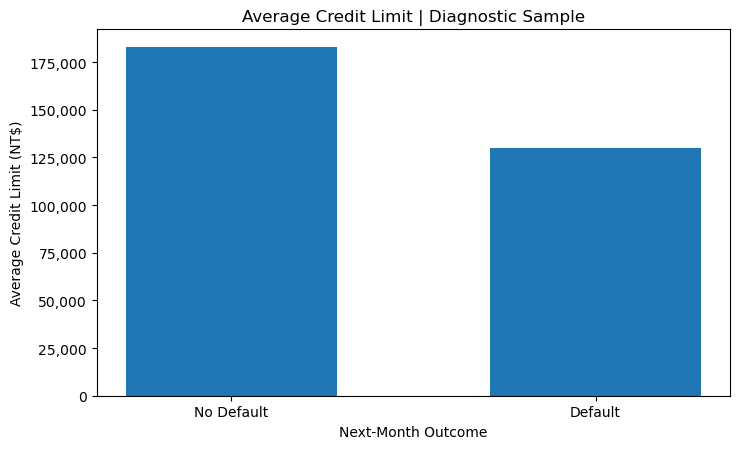

In [72]:
promedios = (
    datos_diagnostico
    .groupby("Y")["X1"]
    .mean()
    .reindex([0, 1])
)

plt.figure(figsize=(7.5, 4.6))

plt.bar(
    ["No Default", "Default"],
    promedios.values,
    width=0.58
)

plt.gca().yaxis.set_major_formatter(
    StrMethodFormatter("{x:,.0f}")
)

plt.title("Average Credit Limit | Diagnostic Sample")
plt.xlabel("Next-Month Outcome")
plt.ylabel("Average Credit Limit (NT$)")
plt.tight_layout()
plt.show()


### Monthly Delinquency Rates

La gráfica conserva el cálculo de códigos positivos por clase y ordena los meses de abril a septiembre.


In [73]:
variables_historial = [
    "X6", "X7", "X8",
    "X9", "X10", "X11"
]

nombres_meses = [
    "Septiembre",
    "Agosto",
    "Julio",
    "Junio",
    "Mayo",
    "Abril"
]

tasas_atraso = []

for variable, mes in zip(
    variables_historial,
    nombres_meses
):
    
    tabla = (
        datos_diagnostico
        .groupby("Y")[variable]
        .apply(
            lambda x: (x > 0).mean() * 100
        )
    )
    
    tasas_atraso.append({
        "Mes": mes,
        "No Default": tabla[0],
        "Default": tabla[1]
    })

tasas_atraso = pd.DataFrame(
    tasas_atraso
)

tasas_atraso.round(2)


,Mes,No Default,Default
0,Septiembre,10.78,51.67
1,Agosto,4.25,37.31
2,Julio,3.79,33.18
3,Junio,2.76,28.32
4,Mayo,2.32,24.85
5,Abril,3.49,24.28


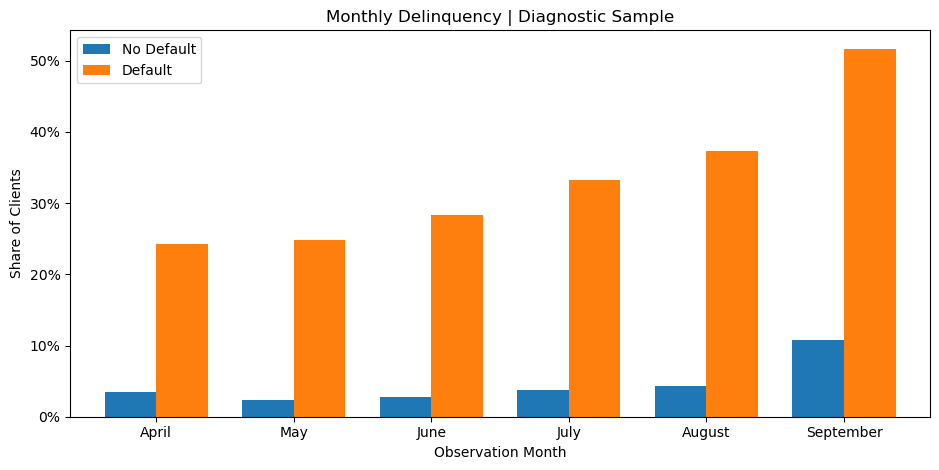

In [74]:
tasas_atraso.set_index("Mes").reindex(
    MONTHS_ES
).rename(
    index=MONTH_EN
).plot(
    kind="bar",
    figsize=(9.5, 4.8),
    width=0.75
)

plt.xticks(rotation=0)

# Las tasas ya están expresadas en escala 0–100
plt.gca().yaxis.set_major_formatter(
    PercentFormatter(xmax=100)
)

plt.title("Monthly Delinquency | Diagnostic Sample")
plt.xlabel("Observation Month")
plt.ylabel("Share of Clients")
plt.tight_layout()
plt.show()


### Total Delinquent Months


In [75]:
meses_incumplimiento = pd.crosstab(
    datos_diagnostico["meses_atraso"],
    datos_diagnostico["Y"],
    normalize="columns"
) * 100

meses_incumplimiento.columns = [
    "No Default",
    "Default"
]

meses_incumplimiento.round(2)


,No Default,Default
meses_atraso,,
0,79.77,35.17
1,14.08,19.89
2,5.27,11.09
3,0.73,8.85
4,0.15,8.21
5,0.00,2.58
6,0.00,14.21


In [76]:
datos_diagnostico.groupby("Y")[
    "meses_atraso"
].agg([
    "mean",
    "median",
    "std"
]).round(2)


,mean,median,std
Y,,,
0,0.27,0.0,0.60
1,2.00,1.0,2.13


### Consecutive Delinquency Runs

Las rachas de tres o más meses no tienen registros con `Y = 0` en esta muestra por construcción del filtro. Conviene recordarlo al interpretar su poder de separación.


In [77]:
rachas = pd.crosstab(
    datos_diagnostico["racha_max_atraso"],
    datos_diagnostico["Y"]
)

rachas.columns = [
    "No Default",
    "Default"
]

rachas


,No Default,Default
racha_max_atraso,,
0,17597,2334
1,3338,1504
2,1124,806
3,0,543
4,0,339
5,0,167
6,0,943


### Statement Balances


In [78]:
variables_bill = [
    "X12", "X13", "X14",
    "X15", "X16", "X17"
]

bill = (
    datos_diagnostico
    .groupby("Y")[variables_bill]
    .mean()
    .T
)

bill.columns = [
    "No Default",
    "Default"
]

bill.index = [
    "Septiembre",
    "Agosto",
    "Julio",
    "Junio",
    "Mayo",
    "Abril"
]

bill.round(2)


,No Default,Default
Septiembre,52046.95,48509.16
Agosto,49605.74,47283.62
Julio,47314.95,45181.60
Junio,43252.04,42036.95
Mayo,40092.02,39540.19
Abril,38590.11,38271.44


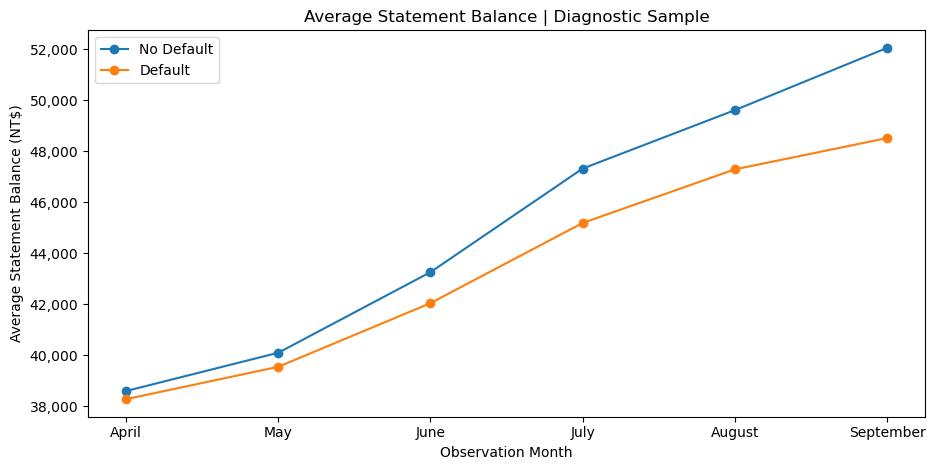

In [79]:
bill.reindex(
    MONTHS_ES
).rename(
    index=MONTH_EN
).plot(
    kind="line",
    marker="o",
    figsize=(9.5, 4.8)
)

plt.gca().yaxis.set_major_formatter(
    StrMethodFormatter("{x:,.0f}")
)

plt.title("Average Statement Balance | Diagnostic Sample")
plt.xlabel("Observation Month")
plt.ylabel("Average Statement Balance (NT$)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Payment Amounts


In [80]:
variables_pagos = [
    "X18", "X19", "X20",
    "X21", "X22", "X23"
]

pagos = (
    datos_diagnostico
    .groupby("Y")[variables_pagos]
    .mean()
    .T
)

pagos.columns = [
    "No Default",
    "Default"
]

pagos.index = [
    "Septiembre",
    "Agosto",
    "Julio",
    "Junio",
    "Mayo",
    "Abril"
]

pagos.round(2)


,No Default,Default
Septiembre,6502.11,3397.04
Agosto,6874.35,3388.65
Julio,5964.84,3367.35
Junio,5458.84,3155.63
Mayo,5413.89,3219.14
Abril,5865.72,3441.48


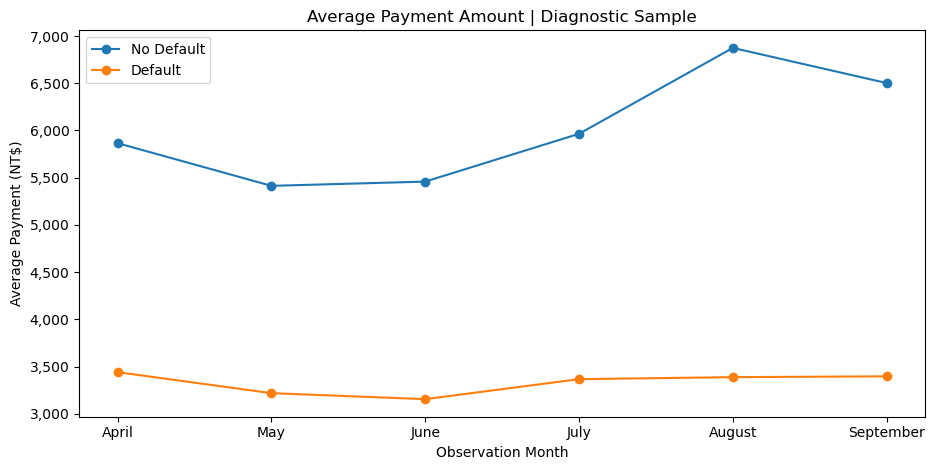

In [81]:
pagos.reindex(
    MONTHS_ES
).rename(
    index=MONTH_EN
).plot(
    kind="line",
    marker="o",
    figsize=(9.5, 4.8)
)

plt.gca().yaxis.set_major_formatter(
    StrMethodFormatter("{x:,.0f}")
)

plt.title("Average Payment Amount | Diagnostic Sample")
plt.xlabel("Observation Month")
plt.ylabel("Average Payment (NT$)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Credit Utilization

Calculamos saldo facturado dividido entre límite para cada mes. La mediana reduce el peso de los valores altos al describir el grupo, pero no modifica los valores individuales usados después.


In [82]:
bills = [
    "X12", "X13", "X14",
    "X15", "X16", "X17"
]

meses = [
    "Sep", "Ago", "Jul",
    "Jun", "May", "Abr"
]

for bill_col, mes in zip(
    bills,
    meses
):
    
    datos_diagnostico[
        f"utilizacion_{mes}"
    ] = (
        datos_diagnostico[bill_col] /
        datos_diagnostico["X1"]
    )


In [83]:
cols_utilizacion = [
    f"utilizacion_{mes}"
    for mes in meses
]

utilizacion = (
    datos_diagnostico
    .groupby("Y")[cols_utilizacion]
    .median()
    .T
)

utilizacion.columns = [
    "No Default",
    "Default"
]

utilizacion.index = [
    "Septiembre",
    "Agosto",
    "Julio",
    "Junio",
    "Mayo",
    "Abril"
]

utilizacion.round(3)


,No Default,Default
Septiembre,0.232,0.493
Agosto,0.216,0.494
Julio,0.195,0.463
Junio,0.172,0.407
Mayo,0.153,0.373
Abril,0.130,0.352


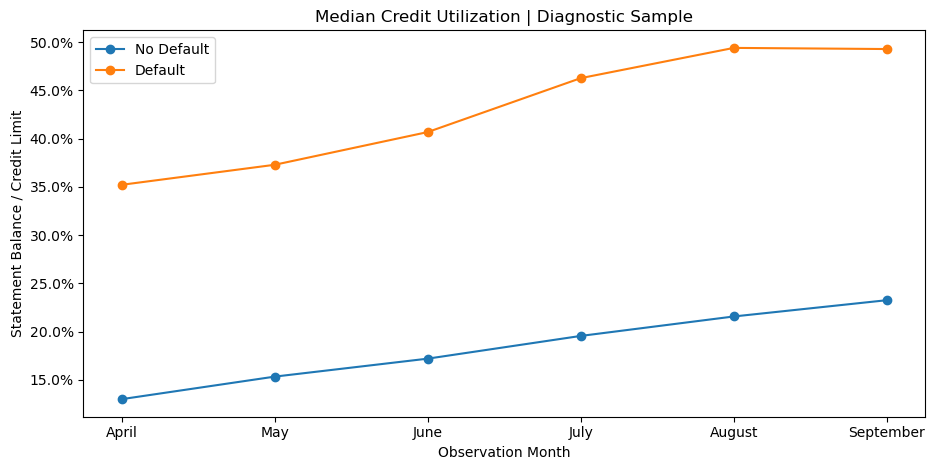

In [84]:
utilizacion.reindex(
    MONTHS_ES
).rename(
    index=MONTH_EN
).plot(
    kind="line",
    marker="o",
    figsize=(9.5, 4.8)
)

plt.gca().yaxis.set_major_formatter(
    PercentFormatter(xmax=1)
)

plt.title("Median Credit Utilization | Diagnostic Sample")
plt.xlabel("Observation Month")
plt.ylabel("Statement Balance / Credit Limit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Payment-to-Balance Ratio


Para septiembre, el código divide el pago entre el saldo facturado y restringe este resumen a saldos positivos:

$$\text{Payment Ratio}=\frac{\text{Pago de septiembre}}{\text{Saldo facturado de septiembre}}.$$



In [85]:
datos_ratio = datos_diagnostico[
    datos_diagnostico["X12"] > 0
].copy()

datos_ratio["payment_ratio_sep"] = (
    datos_ratio["X18"] /
    datos_ratio["X12"]
)

payment_ratio = (
    datos_ratio
    .groupby("Y")[
        "payment_ratio_sep"
    ]
    .agg([
        "mean",
        "median"
    ])
)

payment_ratio.index = [
    "No Default",
    "Default"
]

payment_ratio.round(3)


,mean,median
No Default,2.148,0.068
Default,0.880,0.050


### Diagnostic-Sample Summary

Reunimos las principales diferencias de límite, atrasos, saldos, pagos y utilización antes de pasar a la selección de variables.


In [86]:
resumen = pd.DataFrame({
    
    "No Default": [
        
        datos_diagnostico[
            datos_diagnostico["Y"] == 0
        ]["X1"].mean(),
        
        datos_diagnostico[
            datos_diagnostico["Y"] == 0
        ]["meses_atraso"].mean(),
        
        datos_diagnostico[
            datos_diagnostico["Y"] == 0
        ]["X12"].mean(),
        
        datos_diagnostico[
            datos_diagnostico["Y"] == 0
        ]["X18"].mean(),
        
        datos_diagnostico[
            datos_diagnostico["Y"] == 0
        ]["utilizacion_Sep"].median()
    ],
    
    "Default": [
        
        datos_diagnostico[
            datos_diagnostico["Y"] == 1
        ]["X1"].mean(),
        
        datos_diagnostico[
            datos_diagnostico["Y"] == 1
        ]["meses_atraso"].mean(),
        
        datos_diagnostico[
            datos_diagnostico["Y"] == 1
        ]["X12"].mean(),
        
        datos_diagnostico[
            datos_diagnostico["Y"] == 1
        ]["X18"].mean(),
        
        datos_diagnostico[
            datos_diagnostico["Y"] == 1
        ]["utilizacion_Sep"].median()
    ]
    
}, index=[
    "Límite de crédito promedio",
    "Meses con atraso promedio",
    "Bill septiembre promedio",
    "Pago septiembre promedio",
    "Utilización septiembre mediana"
])

resumen.round(2)


,No Default,Default
Límite de crédito promedio,183039.67,130109.66
Meses con atraso promedio,0.27,2.00
Bill septiembre promedio,52046.95,48509.16
Pago septiembre promedio,6502.11,3397.04
Utilización septiembre mediana,0.23,0.49


## 5.  Monthly Distribution Changes

El PSI compara la distribución de cada mes histórico con abril usando la **cartera completa**. Aquí describe cuánto cambia la distribución de una variable dentro de la ventana de seis meses de los mismos clientes; no debe interpretarse como validación temporal del modelo en cohortes futuras.

Los umbrales 0.10 y 0.25 se conservan únicamente como referencias orientativas.


In [87]:
def calcular_psi_continuo(referencia, actual, bins=10):
    
    referencia = pd.Series(referencia).dropna()
    actual = pd.Series(actual).dropna()

    # Cortes determinados únicamente por la población de referencia
    cortes = np.unique(
        referencia.quantile(
            np.linspace(0, 1, bins + 1)
        ).values
    )

    # Extremos abiertos para capturar valores futuros
    cortes[0] = -np.inf
    cortes[-1] = np.inf

    ref_bins = pd.cut(
        referencia,
        bins=cortes,
        include_lowest=True
    )

    act_bins = pd.cut(
        actual,
        bins=cortes,
        include_lowest=True
    )

    ref_dist = (
        ref_bins.value_counts(
            normalize=True,
            sort=False
        )
    )

    act_dist = (
        act_bins.value_counts(
            normalize=True,
            sort=False
        )
        .reindex(ref_dist.index, fill_value=0)
    )

    epsilon = 0.0001

    ref_dist = ref_dist.clip(lower=epsilon)
    act_dist = act_dist.clip(lower=epsilon)

    psi = np.sum(
        (act_dist - ref_dist) *
        np.log(act_dist / ref_dist)
    )

    return psi


In [88]:
def calcular_psi_categorico(referencia, actual):
    
    referencia = pd.Series(referencia).dropna()
    actual = pd.Series(actual).dropna()
    
    categorias = sorted(
        set(referencia.unique()) |
        set(actual.unique())
    )

    ref_dist = (
        referencia
        .value_counts(normalize=True)
        .reindex(categorias, fill_value=0)
    )

    act_dist = (
        actual
        .value_counts(normalize=True)
        .reindex(categorias, fill_value=0)
    )

    epsilon = 0.0001

    ref_dist = ref_dist.clip(lower=epsilon)
    act_dist = act_dist.clip(lower=epsilon)

    psi = np.sum(
        (act_dist - ref_dist) *
        np.log(act_dist / ref_dist)
    )

    return psi


In [89]:
meses = [
    "Abril",
    "Mayo",
    "Junio",
    "Julio",
    "Agosto",
    "Septiembre"
]

pay_status = {
    "Abril": "X11",
    "Mayo": "X10",
    "Junio": "X9",
    "Julio": "X8",
    "Agosto": "X7",
    "Septiembre": "X6"
}

bill_amount = {
    "Abril": "X17",
    "Mayo": "X16",
    "Junio": "X15",
    "Julio": "X14",
    "Agosto": "X13",
    "Septiembre": "X12"
}

payment_amount = {
    "Abril": "X23",
    "Mayo": "X22",
    "Junio": "X21",
    "Julio": "X20",
    "Agosto": "X19",
    "Septiembre": "X18"
}


In [90]:
resultados_pay = []

referencia = datos[
    pay_status["Abril"]
]

for mes in meses:
    
    actual = datos[
        pay_status[mes]
    ]
    
    psi = calcular_psi_categorico(
        referencia,
        actual
    )
    
    resultados_pay.append({
        "Mes": mes,
        "PSI": psi
    })

psi_pay = pd.DataFrame(resultados_pay)

psi_pay


,Mes,PSI
0,Abril,0.000000
1,Mayo,0.003761
2,Junio,0.005649
3,Julio,0.018389
4,Agosto,0.031152
5,Septiembre,0.926396


In [91]:
resultados_bill = []

referencia = datos[
    bill_amount["Abril"]
]

for mes in meses:
    
    actual = datos[
        bill_amount[mes]
    ]
    
    psi = calcular_psi_continuo(
        referencia,
        actual,
        bins=10
    )
    
    resultados_bill.append({
        "Mes": mes,
        "PSI": psi
    })

psi_bill = pd.DataFrame(resultados_bill)

psi_bill


,Mes,PSI
0,Abril,0.000000
1,Mayo,0.003102
2,Junio,0.009533
3,Julio,0.024848
4,Agosto,0.043622
5,Septiembre,0.075263


In [92]:
resultados_payment = []

referencia = datos[
    payment_amount["Abril"]
]

for mes in meses:
    
    actual = datos[
        payment_amount[mes]
    ]
    
    psi = calcular_psi_continuo(
        referencia,
        actual,
        bins=10
    )
    
    resultados_payment.append({
        "Mes": mes,
        "PSI": psi
    })

psi_payment = pd.DataFrame(
    resultados_payment
)

psi_payment


,Mes,PSI
0,Abril,0.000000
1,Mayo,0.001142
2,Junio,0.001926
3,Julio,0.029382
4,Agosto,0.140798
5,Septiembre,0.180879


In [93]:
psi_total = pd.DataFrame({
    
    "Mes": meses,
    
    "PAY_STATUS": psi_pay["PSI"],
    
    "BILL_AMOUNT": psi_bill["PSI"],
    
    "PAYMENT_AMOUNT": psi_payment["PSI"]
    
})

psi_total.round(4)


,Mes,PAY_STATUS,BILL_AMOUNT,PAYMENT_AMOUNT
0,Abril,0.0000,0.0000,0.0000
1,Mayo,0.0038,0.0031,0.0011
2,Junio,0.0056,0.0095,0.0019
3,Julio,0.0184,0.0248,0.0294
4,Agosto,0.0312,0.0436,0.1408
5,Septiembre,0.9264,0.0753,0.1809


In [94]:
def clasificar_psi(valor):
    
    if valor < 0.10:
        return "Estable"
    
    elif valor < 0.25:
        return "Cambio moderado"
    
    else:
        return "Cambio importante"


In [95]:
for variable in [
    "PAY_STATUS",
    "BILL_AMOUNT",
    "PAYMENT_AMOUNT"
]:
    
    psi_total[
        variable + "_Interpretacion"
    ] = (
        psi_total[variable]
        .apply(clasificar_psi)
    )

psi_total


,Mes,PAY_STATUS,BILL_AMOUNT,PAYMENT_AMOUNT,PAY_STATUS_Interpretacion,BILL_AMOUNT_Interpretacion,PAYMENT_AMOUNT_Interpretacion
0,Abril,0.000000,0.000000,0.000000,Estable,Estable,Estable
1,Mayo,0.003761,0.003102,0.001142,Estable,Estable,Estable
2,Junio,0.005649,0.009533,0.001926,Estable,Estable,Estable
3,Julio,0.018389,0.024848,0.029382,Estable,Estable,Estable
4,Agosto,0.031152,0.043622,0.140798,Estable,Estable,Cambio moderado
5,Septiembre,0.926396,0.075263,0.180879,Cambio importante,Estable,Cambio moderado


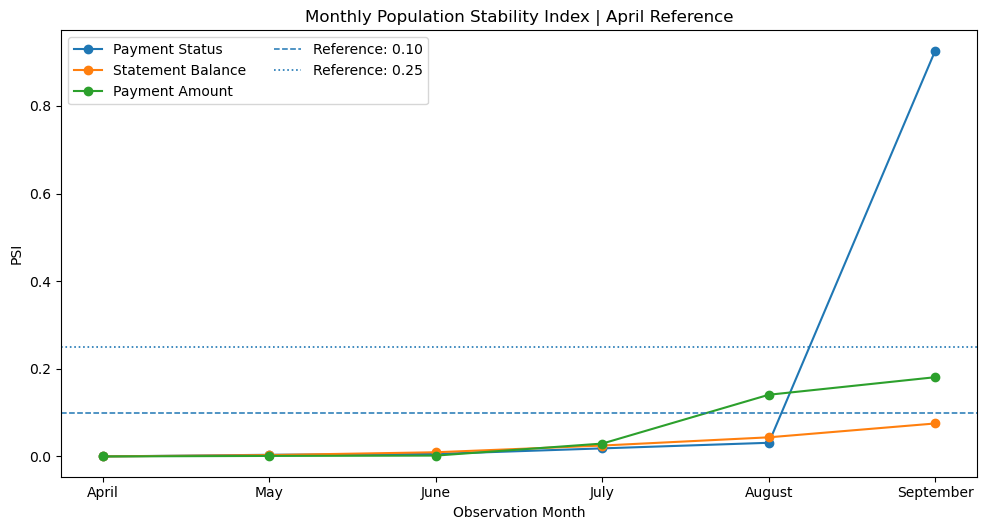

In [96]:
plt.figure(figsize=(10, 5.4))

for column, label in [
    ("PAY_STATUS", "Payment Status"),
    ("BILL_AMOUNT", "Statement Balance"),
    ("PAYMENT_AMOUNT", "Payment Amount")
]:
    plt.plot(
        psi_total["Mes"].map(MONTH_EN),
        psi_total[column],
        marker="o",
        label=label
    )

plt.axhline(
    0.10,
    linestyle="--",
    linewidth=1.1,
    label="Reference: 0.10"
)

plt.axhline(
    0.25,
    linestyle=":",
    linewidth=1.2,
    label="Reference: 0.25"
)

plt.title("Monthly Population Stability Index | April Reference")
plt.xlabel("Observation Month")
plt.ylabel("PSI")
plt.xticks(rotation=0)
plt.legend(ncol=2, loc="best")
plt.tight_layout()
plt.show()


In [97]:
def psi_por_grupo(
    datos,
    columnas,
    tipo="continuo"
):
    
    resultados = []

    for y, nombre in [
        (0, "No Default"),
        (1, "Default")
    ]:
        
        df = datos[
            datos["Y"] == y
        ]
        
        referencia = df[
            columnas["Abril"]
        ]
        
        for mes in meses:
            
            actual = df[
                columnas[mes]
            ]
            
            if tipo == "categorico":
                
                psi = calcular_psi_categorico(
                    referencia,
                    actual
                )
                
            else:
                
                psi = calcular_psi_continuo(
                    referencia,
                    actual
                )
            
            resultados.append({
                "Grupo": nombre,
                "Mes": mes,
                "PSI": psi
            })
    
    return pd.DataFrame(resultados)


In [98]:
psi_pay_grupo = psi_por_grupo(
    datos,
    pay_status,
    tipo="categorico"
)

psi_bill_grupo = psi_por_grupo(
    datos,
    bill_amount
)

psi_payment_grupo = psi_por_grupo(
    datos,
    payment_amount
)


In [99]:
psi_pay_grupo.pivot(
    index="Mes",
    columns="Grupo",
    values="PSI"
).round(4)


Grupo,Default,No Default
Mes,,
Abril,0.0000,0.0000
Agosto,0.1004,0.0183
Julio,0.0464,0.0123
Junio,0.0172,0.0032
Mayo,0.0077,0.0032
Septiembre,1.6462,0.7690


### Grouped Payment Status

Repetimos el PSI con estados agrupados y después con un indicador binario. Esto muestra cuánto depende el diagnóstico del nivel de detalle utilizado. Las etiquetas se conservan tal como fueron definidas en el caso.


In [100]:
def categorizar_pay(x):
    
    if x <= 0:
        return "Sin atraso"
    
    elif x == 1:
        return "1 mes"
    
    elif x == 2:
        return "2 meses"
    
    else:
        return "3+ meses"


In [101]:
for mes, columna in pay_status.items():
    
    datos[
        f"pay_cat_{mes}"
    ] = (
        datos[columna]
        .apply(categorizar_pay)
    )


In [102]:
resultados_pay_agrupado = []

referencia = datos[
    "pay_cat_Abril"
]

for mes in meses:
    
    actual = datos[
        f"pay_cat_{mes}"
    ]
    
    psi = calcular_psi_categorico(
        referencia,
        actual
    )
    
    resultados_pay_agrupado.append({
        "Mes": mes,
        "PSI": psi
    })

psi_pay_agrupado = pd.DataFrame(
    resultados_pay_agrupado
)

psi_pay_agrupado


,Mes,PSI
0,Abril,0.000000
1,Mayo,0.000343
2,Junio,0.002103
3,Julio,0.013524
4,Agosto,0.020229
5,Septiembre,0.894579


In [103]:
def categorizar_atraso(x):
    
    if x > 0:
        return "Con atraso"
    
    return "Sin atraso"


In [104]:
for mes, columna in pay_status.items():
    
    datos[
        f"atraso_psi_{mes}"
    ] = (
        datos[columna]
        .apply(categorizar_atraso)
    )


In [105]:
resultados_atraso = []

referencia = datos[
    "atraso_psi_Abril"
]

for mes in meses:
    
    actual = datos[
        f"atraso_psi_{mes}"
    ]
    
    psi = calcular_psi_categorico(
        referencia,
        actual
    )
    
    resultados_atraso.append({
        "Mes": mes,
        "PSI": psi
    })

psi_atraso = pd.DataFrame(
    resultados_atraso
)

psi_atraso


,Mes,PSI
0,Abril,0.000000
1,Mayo,0.000151
2,Junio,0.002114
3,Julio,0.013480
4,Agosto,0.018908
5,Septiembre,0.117715


## 6. Train/Test Split and Variable Selection

Primero reservamos una muestra de prueba estratificada 70/30 (`random_state = 42`). A partir de este punto, **IV, correlación con `Y` y correlación entre candidatas se calculan únicamente con train**. El test no participa en ninguna decisión de selección de variables.

El IV resume cuánto difieren las distribuciones de eventos y no-eventos dentro de los intervalos de una variable. Para pares con correlación absoluta de al menos **0.75**, conservamos la variable de mayor IV; la correlación absoluta con `Y` funciona como desempate.


In [106]:
variables_candidatas = [
    "X1",
    "X6",
    "X7",
    "racha_max_atraso",
    "utilizacion_Sep",
    "utilizacion_Ago",
    "X18",
    "X19"
]

target = "Y"

datos_modelado_base = (
    datos[variables_candidatas + [target]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .copy()
)

X_base = datos_modelado_base[variables_candidatas]
y_base = datos_modelado_base[target]

X_train_base, X_test_base, y_train, y_test = train_test_split(
    X_base,
    y_base,
    test_size=0.30,
    random_state=42,
    stratify=y_base
)

train_seleccion = X_train_base.copy()
train_seleccion[target] = y_train

print("Muestra modelable:", len(datos_modelado_base))
print("Train:", X_train_base.shape)
print("Test:", X_test_base.shape)
print("Default Train:", round(y_train.mean() * 100, 2), "%")
print("Default Test:", round(y_test.mean() * 100, 2), "%")


Muestra modelable: 30000
Train: (21000, 8)
Test: (9000, 8)
Default Train: 22.12 %
Default Test: 22.12 %


In [107]:
corr_target = (
    train_seleccion[variables_candidatas + [target]]
    .corr()[target]
    .drop(target)
)

corr_target = pd.DataFrame({
    "Variable": corr_target.index,
    "Correlacion_Y": corr_target.values
})

corr_target["Abs_Correlacion_Y"] = corr_target["Correlacion_Y"].abs()
corr_target


,Variable,Correlacion_Y,Abs_Correlacion_Y
0,X1,-0.159213,0.159213
1,X6,0.327370,0.327370
2,X7,0.267821,0.267821
3,racha_max_atraso,0.393179,0.393179
4,utilizacion_Sep,0.088542,0.088542
5,utilizacion_Ago,0.099667,0.099667
6,X18,-0.070114,0.070114
7,X19,-0.066631,0.066631


In [108]:
corr_target["Relacion_pct"] = (
    corr_target["Abs_Correlacion_Y"] * 100
)

corr_target.sort_values(
    "Abs_Correlacion_Y",
    ascending=False
)


,Variable,Correlacion_Y,Abs_Correlacion_Y,Relacion_pct
3,racha_max_atraso,0.393179,0.393179,39.317923
1,X6,0.327370,0.327370,32.736965
2,X7,0.267821,0.267821,26.782068
0,X1,-0.159213,0.159213,15.921267
5,utilizacion_Ago,0.099667,0.099667,9.966711
4,utilizacion_Sep,0.088542,0.088542,8.854191
6,X18,-0.070114,0.070114,7.011419
7,X19,-0.066631,0.066631,6.663083


### IV Implementation Note

El archivo invoca `calcular_iv`, pero no incluye su definición. Para ejecutarlo desde un kernel limpio se incorpora una implementación de apoyo: diez grupos por cuantiles cuando hay más de diez valores distintos, categorías en otro caso y suavizado de 0.5 en los conteos de ambas clases. **Reproduce los ocho IV guardados al redondeo mostrado**, sin cambiar las siete variables utilizadas por los modelos. No se presenta como recuperación del código original ausente.


In [109]:
def calcular_iv(data, variable, target="Y", bins=10):
    """Implementación de apoyo compatible con los IV guardados en el original."""
    work = data[[variable, target]].dropna().copy()
    if work[variable].nunique() > bins:
        group = pd.qcut(work[variable], q=bins, duplicates="drop")
    else:
        group = work[variable]
    counts = work.groupby(group, observed=True)[target].agg(["count", "sum"])
    events = counts["sum"] + 0.5
    non_events = counts["count"] - counts["sum"] + 0.5
    p_event = events / events.sum()
    p_non_event = non_events / non_events.sum()
    return float(((p_non_event - p_event) * np.log(p_non_event / p_event)).sum())


In [110]:
resultados_iv = []

for variable in variables_candidatas:
    iv = calcular_iv(
        train_seleccion,
        variable,
        target="Y"
    )
    resultados_iv.append({
        "Variable": variable,
        "IV": iv
    })

iv_df = pd.DataFrame(resultados_iv)
iv_df


,Variable,IV
0,X1,0.196331
1,X6,0.887396
2,X7,0.553719
3,racha_max_atraso,0.874705
4,utilizacion_Sep,0.075511
5,utilizacion_Ago,0.082391
6,X18,0.160268
7,X19,0.149571


In [111]:
ranking_variables = (
    iv_df
    .merge(
        corr_target,
        on="Variable",
        how="left"
    )
)

ranking_variables = (
    ranking_variables
    .sort_values(
        ["IV", "Abs_Correlacion_Y"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

ranking_variables.round(4)


,Variable,IV,Correlacion_Y,Abs_Correlacion_Y,Relacion_pct
0,X6,0.8874,0.3274,0.3274,32.7370
1,racha_max_atraso,0.8747,0.3932,0.3932,39.3179
2,X7,0.5537,0.2678,0.2678,26.7821
3,X1,0.1963,-0.1592,0.1592,15.9213
4,X18,0.1603,-0.0701,0.0701,7.0114
5,X19,0.1496,-0.0666,0.0666,6.6631
6,utilizacion_Ago,0.0824,0.0997,0.0997,9.9667
7,utilizacion_Sep,0.0755,0.0885,0.0885,8.8542


In [112]:
matriz_corr = X_train_base[variables_candidatas].corr()
matriz_corr.round(2)


,X1,X6,X7,racha_max_atraso,utilizacion_Sep,utilizacion_Ago,X18,X19
X1,1.00,-0.27,-0.30,-0.24,-0.37,-0.37,0.19,0.19
X6,-0.27,1.00,0.67,0.62,0.38,0.38,-0.08,-0.07
X7,-0.30,0.67,1.00,0.66,0.47,0.47,-0.08,-0.06
racha_max_atraso,-0.24,0.62,0.66,1.00,0.14,0.17,-0.08,-0.07
utilizacion_Sep,-0.37,0.38,0.47,0.14,1.00,0.93,-0.02,-0.03
utilizacion_Ago,-0.37,0.38,0.47,0.17,0.93,1.00,0.09,-0.04
X18,0.19,-0.08,-0.08,-0.08,-0.02,0.09,1.00,0.33
X19,0.19,-0.07,-0.06,-0.07,-0.03,-0.04,0.33,1.00


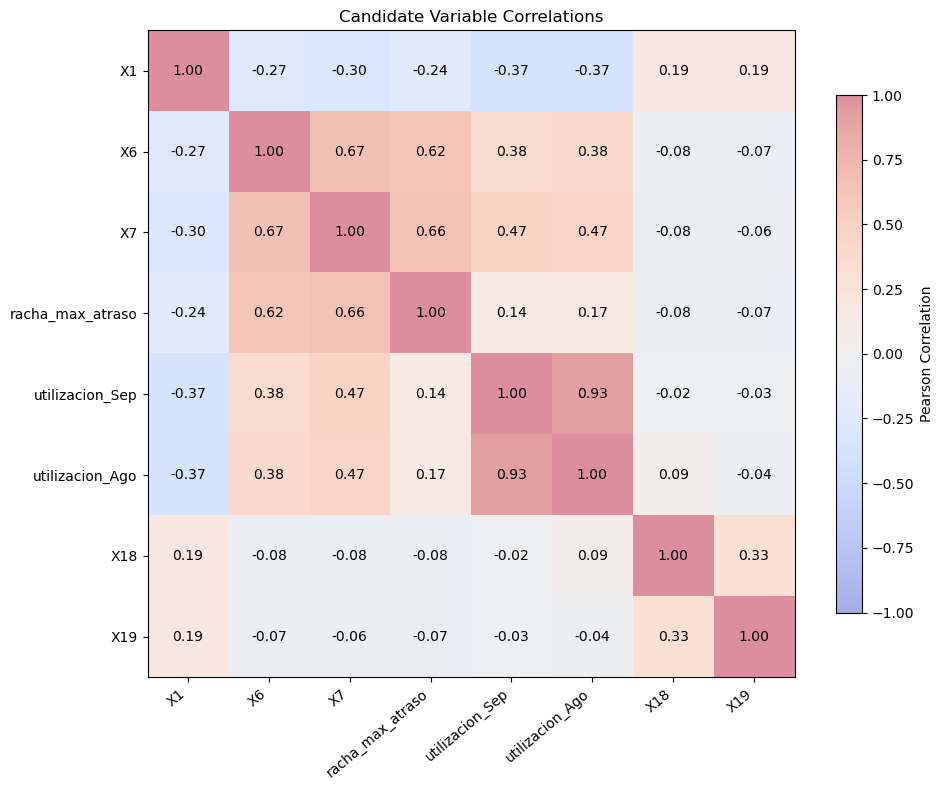

In [113]:
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    matriz_corr.values,
    vmin=-1,
    vmax=1,
    aspect="equal",
    alpha=0.45,
    cmap="coolwarm"
)

ax.set_xticks(
    range(len(matriz_corr.columns)),
    labels=matriz_corr.columns,
    rotation=40,
    ha="right"
)

ax.set_yticks(
    range(len(matriz_corr.index)),
    labels=matriz_corr.index
)

for i in range(len(matriz_corr.index)):
    for j in range(len(matriz_corr.columns)):
        ax.text(
            j,
            i,
            f"{matriz_corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=10
        )

fig.colorbar(
    im,
    ax=ax,
    shrink=0.8,
    label="Pearson Correlation"
)

ax.set_title("Candidate Variable Correlations")
ax.grid(False)
fig.tight_layout()
plt.show()


In [114]:
umbral = 0.75

pares_alta_corr = []

for i in range(len(variables_candidatas)):
    
    for j in range(i + 1, len(variables_candidatas)):
        
        var1 = variables_candidatas[i]
        var2 = variables_candidatas[j]
        
        corr = abs(
            matriz_corr.loc[var1, var2]
        )
        
        if corr >= umbral:
            
            pares_alta_corr.append({
                "Variable_1": var1,
                "Variable_2": var2,
                "Correlacion": corr
            })

pares_alta_corr = pd.DataFrame(
    pares_alta_corr
)

pares_alta_corr


,Variable_1,Variable_2,Correlacion
0,utilizacion_Sep,utilizacion_Ago,0.932478


In [115]:
comparacion_pares = []

for _, fila in pares_alta_corr.iterrows():
    
    var1 = fila["Variable_1"]
    var2 = fila["Variable_2"]
    
    info1 = ranking_variables[
        ranking_variables["Variable"] == var1
    ].iloc[0]
    
    info2 = ranking_variables[
        ranking_variables["Variable"] == var2
    ].iloc[0]
    
    comparacion_pares.append({
        
        "Variable_1": var1,
        "IV_1": info1["IV"],
        "Corr_Y_1": info1["Abs_Correlacion_Y"],
        
        "Variable_2": var2,
        "IV_2": info2["IV"],
        "Corr_Y_2": info2["Abs_Correlacion_Y"],
        
        "Corr_entre_variables":
            fila["Correlacion"]
    })

comparacion_pares = pd.DataFrame(
    comparacion_pares
)

comparacion_pares.round(4)


,Variable_1,IV_1,Corr_Y_1,Variable_2,IV_2,Corr_Y_2,Corr_entre_variables
0,utilizacion_Sep,0.0755,0.0885,utilizacion_Ago,0.0824,0.0997,0.9325


In [116]:
variables_eliminar = []

for _, fila in pares_alta_corr.iterrows():
    
    var1 = fila["Variable_1"]
    var2 = fila["Variable_2"]
    
    info1 = ranking_variables[
        ranking_variables["Variable"] == var1
    ].iloc[0]
    
    info2 = ranking_variables[
        ranking_variables["Variable"] == var2
    ].iloc[0]
    
    # Primero comparamos IV
    if info1["IV"] > info2["IV"]:
        
        variables_eliminar.append(var2)
        
    elif info2["IV"] > info1["IV"]:
        
        variables_eliminar.append(var1)
        
    else:
        
        # Si empatan en IV,
        # usamos correlación con Y
        
        if (
            info1["Abs_Correlacion_Y"]
            >=
            info2["Abs_Correlacion_Y"]
        ):
            
            variables_eliminar.append(var2)
            
        else:
            
            variables_eliminar.append(var1)


In [117]:
variables_eliminar = list(
    set(variables_eliminar)
)

print(
    "Variables a eliminar:",
    variables_eliminar
)


Variables a eliminar: ['utilizacion_Sep']


In [118]:
variables_finales = [
    var
    for var in variables_candidatas
    if var not in variables_eliminar
]

print(
    "Variables finales:"
)

for variable in variables_finales:
    print(variable)


Variables finales:
X1
X6
X7
racha_max_atraso
utilizacion_Ago
X18
X19


In [119]:
variables_modelo = variables_finales.copy()

X_train = X_train_base[variables_modelo].copy()
X_test = X_test_base[variables_modelo].copy()

print("Variables usadas por los modelos:")
for variable in variables_modelo:
    print("-", variable)

print("\nTrain final:", X_train.shape)
print("Test final:", X_test.shape)


Variables usadas por los modelos:
- X1
- X6
- X7
- racha_max_atraso
- utilizacion_Ago
- X18
- X19

Train final: (21000, 7)
Test final: (9000, 7)


## 7. Model Development

Los tres modelos utilizan exactamente las variables seleccionadas con la muestra de entrenamiento. El test reservado permanece intacto hasta la evaluación.

La estandarización se aplica únicamente a la regresión logística dentro de su pipeline. Random Forest e Histogram Gradient Boosting trabajan con las variables en su escala original.


In [120]:
# Verificación final antes de entrenar
print("Valores faltantes en train:", int(X_train.isna().sum().sum()))
print("Valores faltantes en test:", int(X_test.isna().sum().sum()))
print("Valores infinitos en train:", int(np.isinf(X_train.to_numpy()).sum()))
print("Valores infinitos en test:", int(np.isinf(X_test.to_numpy()).sum()))


Valores faltantes en train: 0
Valores faltantes en test: 0
Valores infinitos en train: 0
Valores infinitos en test: 0


In [121]:
# `variables_modelo` proviene directamente de la selección realizada con train
variables_modelo


['X1', 'X6', 'X7', 'racha_max_atraso', 'utilizacion_Ago', 'X18', 'X19']

In [122]:
print("Distribución del target:")
print(
    pd.DataFrame({
        "Train": y_train.value_counts(normalize=True).sort_index(),
        "Test": y_test.value_counts(normalize=True).sort_index()
    }).round(4)
)


Distribución del target:
    Train    Test
Y                
0  0.7788  0.7788
1  0.2212  0.2212


La muestra de prueba ya fue separada **antes** del cálculo de IV y correlaciones. No se vuelve a particionar en esta sección.


**Control de leakage:** ninguna métrica de selección de variables utiliza `X_test` ni `y_test`.


A partir de aquí, los modelos se ajustan con `X_train, y_train` y se comparan sobre los mismos `X_test, y_test`.


### Logistic Regression

Sirve como referencia sencilla: relaciona las variables con el logaritmo de las odds del evento. Conservamos la configuración y el escalado del original.

In [123]:
modelo_logit = Pipeline([
    
    (
        "scaler",
        StandardScaler()
    ),
    
    (
        "modelo",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

modelo_logit.fit(
    X_train,
    y_train
)


,steps,"[('scaler', ...), ('modelo', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [124]:
pd_logit = (
    modelo_logit
    .predict_proba(X_test)[:, 1]
)

pd_logit[:10]


array([0.13710194, 0.18204419, 0.09888801, 0.42176492, 0.16250201,
       0.10571509, 0.11128187, 0.18109741, 0.72854816, 0.16846149])

### Random Forest

El bosque combina árboles que pueden recoger relaciones no lineales. Se mantienen 500 árboles, profundidad máxima 8 y al menos 30 registros por hoja.

In [125]:
modelo_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=30,
    random_state=42,
    n_jobs=-1
)

modelo_rf.fit(
    X_train,
    y_train
)


,n_estimators,500
,criterion,'gini'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,30
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [126]:
pd_rf = (
    modelo_rf
    .predict_proba(X_test)[:, 1]
)

pd_rf[:10]


array([0.05719947, 0.45471448, 0.08925788, 0.55235512, 0.07352749,
       0.07458782, 0.11225195, 0.1875709 , 0.50958156, 0.1310496 ])

### Histogram Gradient Boosting

Este modelo utiliza `HistGradientBoostingClassifier`, no XGBoost. Se conservan las 300 iteraciones, tasa de aprendizaje 0.05, profundidad máxima 5 y mínimo de 30 registros por hoja.

In [127]:
modelo_gb = (
    HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_depth=5,
        min_samples_leaf=30,
        random_state=42
    )
)

modelo_gb.fit(
    X_train,
    y_train
)


,loss,'log_loss'
,learning_rate,0.05
,max_iter,300
,max_leaf_nodes,31
,max_depth,5
,min_samples_leaf,30
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


In [128]:
pd_gb = (
    modelo_gb
    .predict_proba(X_test)[:, 1]
)

pd_gb[:10]


array([0.04858713, 0.46945483, 0.09120679, 0.57518282, 0.07772331,
       0.0640183 , 0.10731624, 0.18563076, 0.45841578, 0.12528331])

### KS Statistic

El KS mide la mayor separación entre las tasas acumuladas de verdaderos y falsos positivos a lo largo de los umbrales.

In [129]:
def calcular_ks(y_real, probabilidad):
    
    fpr, tpr, thresholds = roc_curve(
        y_real,
        probabilidad
    )
    
    ks = np.max(
        tpr - fpr
    )
    
    return ks


### Evaluation Metrics

El Gini se calcula como `2 × ROC_AUC − 1` y resume ordenamiento, no porcentaje de aciertos. KS mide separación entre las distribuciones acumuladas de eventos y no-eventos. Brier y Log Loss evalúan la calidad de las probabilidades; en ambos, menor es mejor.

`Average_Precision` se calcula con `average_precision_score` y resume el desempeño precision-recall. `Error_PD_promedio` compara la PD media con la tasa observada y sirve como chequeo de calibración global.


In [130]:
def evaluar_modelo(
    nombre,
    y_real,
    probabilidad
):
    
    auc = roc_auc_score(
        y_real,
        probabilidad
    )
    
    gini = (
        2 * auc - 1
    )
    
    ks = calcular_ks(
        y_real,
        probabilidad
    )
    
    brier = brier_score_loss(
        y_real,
        probabilidad
    )
    
    logloss = log_loss(
        y_real,
        probabilidad
    )
    
    pr_auc = average_precision_score(
        y_real,
        probabilidad
    )
    
    pd_promedio = (
        probabilidad.mean()
    )
    
    default_real = (
        y_real.mean()
    )
    
    return {
        "Modelo": nombre,
        "ROC_AUC": auc,
        "Gini": gini,
        "KS": ks,
        "Average_Precision": pr_auc,
        "Brier": brier,
        "Log_Loss": logloss,
        "PD_promedio": pd_promedio,
        "Default_observado": default_real,
        "Error_PD_promedio": (
            pd_promedio -
            default_real
        )
    }


### Initial Model Comparison

Comparamos los tres modelos sobre los mismos registros de prueba. Las diferencias provienen de sus predicciones, no de cambiar la muestra evaluada.

In [131]:
resultados = []

resultados.append(
    evaluar_modelo(
        "Regresión Logística",
        y_test,
        pd_logit
    )
)

resultados.append(
    evaluar_modelo(
        "Random Forest",
        y_test,
        pd_rf
    )
)

resultados.append(
    evaluar_modelo(
        "Gradient Boosting",
        y_test,
        pd_gb
    )
)

comparacion_modelos = (
    pd.DataFrame(resultados)
)

comparacion_modelos.round(4)


,Modelo,ROC_AUC,Gini,KS,Average_Precision,Brier,Log_Loss,PD_promedio,Default_observado,Error_PD_promedio
0,Regresión Logística,0.7306,0.4613,0.3865,0.5030,0.1441,0.4575,0.2205,0.2212,-0.0007
1,Random Forest,0.7756,0.5512,0.4072,0.5485,0.1366,0.4336,0.2203,0.2212,-0.0010
2,Gradient Boosting,0.7712,0.5425,0.4013,0.5441,0.1373,0.4358,0.2194,0.2212,-0.0018


### ROC Curves

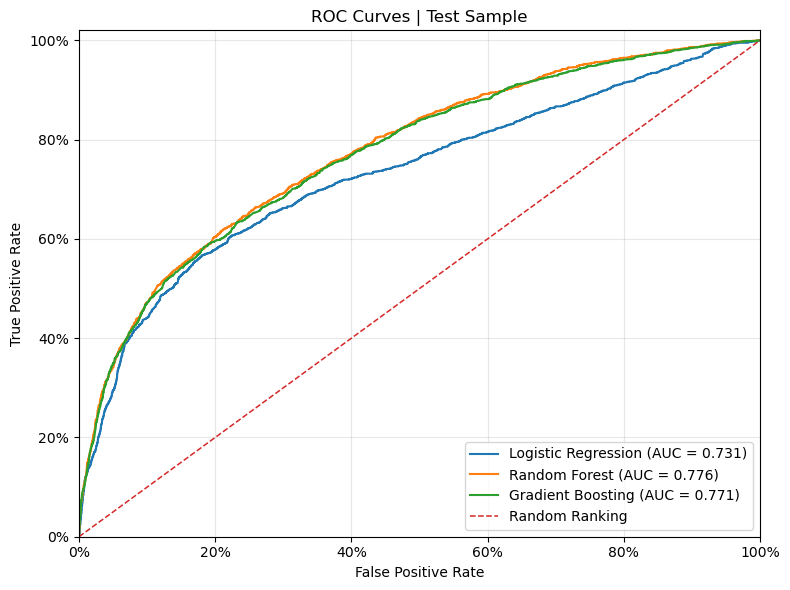

In [132]:
plt.figure(figsize=(8, 6))

for nombre, probabilidad in [
    ("Logistic Regression", pd_logit),
    ("Random Forest", pd_rf),
    ("Gradient Boosting", pd_gb)
]:
    fpr, tpr, _ = roc_curve(y_test, probabilidad)
    auc = roc_auc_score(y_test, probabilidad)

    plt.plot(
        fpr,
        tpr,
        label=f"{nombre} (AUC = {auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.1,
    label="Random Ranking"
)

plt.xlim(0, 1)
plt.ylim(0, 1.02)

plt.gca().xaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1))

plt.title("ROC Curves | Test Sample")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True, axis="both", alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


### Calibration Curves

Cada punto compara la PD media con la tasa observada en un grupo de riesgo. La diagonal representa coincidencia. Las tablas posteriores detallan los grupos del mismo diagnóstico.

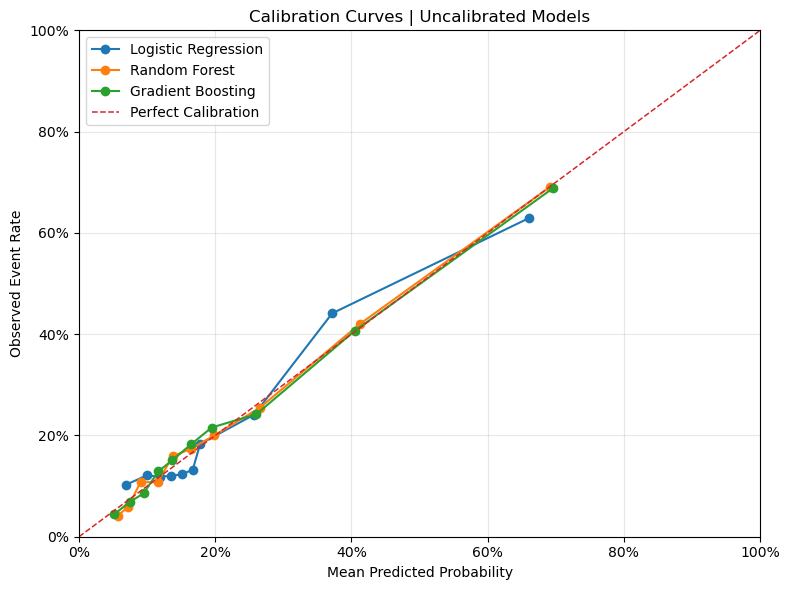

In [133]:
plt.figure(figsize=(8, 6))

for nombre, probabilidad in [
    ("Logistic Regression", pd_logit),
    ("Random Forest", pd_rf),
    ("Gradient Boosting", pd_gb)
]:
    prob_real, prob_predicha = calibration_curve(
        y_test,
        probabilidad,
        n_bins=10,
        strategy="quantile"
    )

    plt.plot(
        prob_predicha,
        prob_real,
        marker="o",
        label=nombre
    )

# Referencia de calibración perfecta
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.1,
    label="Perfect Calibration"
)

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.gca().xaxis.set_major_formatter(
    PercentFormatter(xmax=1)
)
plt.gca().yaxis.set_major_formatter(
    PercentFormatter(xmax=1)
)

plt.title("Calibration Curves | Uncalibrated Models")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Event Rate")
plt.grid(True, axis="both", alpha=0.3)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


In [134]:
def tabla_calibracion(
    y_real,
    probabilidad,
    nombre
):
    
    tabla = pd.DataFrame({
        "Y": np.array(y_real),
        "PD": probabilidad
    })
    
    tabla["Decil_PD"] = pd.qcut(
        tabla["PD"],
        q=10,
        duplicates="drop"
    )
    
    resultado = (
        tabla
        .groupby(
            "Decil_PD",
            observed=True
        )
        .agg(
            Clientes=("Y", "count"),
            PD_promedio=("PD", "mean"),
            Default_observado=("Y", "mean")
        )
        .reset_index()
    )
    
    resultado["Modelo"] = nombre
    
    return resultado


In [135]:
calibracion_logit = (
    tabla_calibracion(
        y_test,
        pd_logit,
        "Logística"
    )
)

calibracion_logit.round(4)


,Decil_PD,Clientes,PD_promedio,Default_observado,Modelo
0,"(-0.00099999678, 0.0884]",900,0.0685,0.1022,Logística
1,"(0.0884, 0.109]",900,0.0993,0.1211,Logística
2,"(0.109, 0.126]",900,0.1182,0.1189,Logística
3,"(0.126, 0.143]",900,0.1346,0.1200,Logística
4,"(0.143, 0.16]",900,0.1507,0.1233,Logística
5,"(0.16, 0.173]",900,0.1669,0.1322,Logística
6,"(0.173, 0.191]",900,0.1779,0.1833,Logística
7,"(0.191, 0.323]",900,0.2572,0.2411,Logística
8,"(0.323, 0.445]",900,0.3717,0.4411,Logística
9,"(0.445, 0.955]",900,0.6601,0.6289,Logística


In [136]:
calibracion_rf = (
    tabla_calibracion(
        y_test,
        pd_rf,
        "Random Forest"
    )
)

calibracion_rf.round(4)


,Decil_PD,Clientes,PD_promedio,Default_observado,Modelo
0,"(0.0355, 0.065]",900,0.0565,0.0411,Random Forest
1,"(0.065, 0.0804]",900,0.0721,0.0589,Random Forest
2,"(0.0804, 0.103]",900,0.0903,0.1078,Random Forest
3,"(0.103, 0.126]",900,0.1157,0.1078,Random Forest
4,"(0.126, 0.151]",900,0.1374,0.1589,Random Forest
5,"(0.151, 0.178]",900,0.1638,0.1733,Random Forest
6,"(0.178, 0.225]",900,0.1984,0.2000,Random Forest
7,"(0.225, 0.308]",905,0.2650,0.2541,Random Forest
8,"(0.308, 0.572]",895,0.4123,0.4201,Random Forest
9,"(0.572, 0.827]",900,0.6919,0.6911,Random Forest


In [137]:
calibracion_gb = (
    tabla_calibracion(
        y_test,
        pd_gb,
        "Gradient Boosting"
    )
)

calibracion_gb.round(4)


,Decil_PD,Clientes,PD_promedio,Default_observado,Modelo
0,"(0.0303, 0.0624]",900,0.0519,0.0444,Gradient Boosting
1,"(0.0624, 0.085]",900,0.0747,0.0689,Gradient Boosting
2,"(0.085, 0.107]",900,0.0948,0.0856,Gradient Boosting
3,"(0.107, 0.126]",900,0.1163,0.1289,Gradient Boosting
4,"(0.126, 0.15]",901,0.1368,0.1509,Gradient Boosting
5,"(0.15, 0.18]",900,0.1642,0.1822,Gradient Boosting
6,"(0.18, 0.219]",900,0.1947,0.2156,Gradient Boosting
7,"(0.219, 0.301]",909,0.2605,0.2420,Gradient Boosting
8,"(0.301, 0.58]",890,0.4050,0.4067,Gradient Boosting
9,"(0.58, 0.833]",900,0.6965,0.6889,Gradient Boosting


### Probability Error

Un buen ordenamiento no asegura probabilidades bien ajustadas. Por eso revisamos Brier y logloss además del Gini.

In [138]:
comparacion_brier = (
    comparacion_modelos[
        [
            "Modelo",
            "Brier",
            "Log_Loss"
        ]
    ]
    .sort_values("Brier")
)

comparacion_brier.round(4)


,Modelo,Brier,Log_Loss
1,Random Forest,0.1366,0.4336
2,Gradient Boosting,0.1373,0.4358
0,Regresión Logística,0.1441,0.4575


## 8. Probability Calibration

Se mantiene la calibración sigmoide con cinco particiones de entrenamiento para Random Forest y Gradient Boosting. Las predicciones se evalúan en el mismo test reservado. La comparación debe comprobar si disminuye el error de probabilidad, no asumir que calibrar siempre mejora.

In [139]:
rf_calibrado = (
    CalibratedClassifierCV(
        estimator=RandomForestClassifier(
            n_estimators=500,
            max_depth=8,
            min_samples_leaf=30,
            random_state=42,
            n_jobs=-1
        ),
        method="sigmoid",
        cv=5
    )
)

rf_calibrado.fit(
    X_train,
    y_train
)

pd_rf_cal = (
    rf_calibrado
    .predict_proba(X_test)[:,1]
)


In [140]:
gb_calibrado = (
    CalibratedClassifierCV(
        estimator=HistGradientBoostingClassifier(
            max_iter=300,
            learning_rate=0.05,
            max_depth=5,
            min_samples_leaf=30,
            random_state=42
        ),
        method="sigmoid",
        cv=5
    )
)

gb_calibrado.fit(
    X_train,
    y_train
)

pd_gb_cal = (
    gb_calibrado
    .predict_proba(X_test)[:,1]
)


### Final Model Comparison

Comparamos logística, Random Forest y Gradient Boosting, junto con las versiones calibradas de los dos modelos de árboles. Todas las métricas se calculan sobre el mismo test reservado; la tasa observada se obtiene del test actual y no se fija manualmente.


In [141]:
resultados_completos = []

modelos_probabilidades = [
    
    (
        "Logística",
        pd_logit
    ),
    
    (
        "Random Forest",
        pd_rf
    ),
    
    (
        "RF calibrado",
        pd_rf_cal
    ),
    
    (
        "Gradient Boosting",
        pd_gb
    ),
    
    (
        "GB calibrado",
        pd_gb_cal
    )
]

for nombre, probabilidad in modelos_probabilidades:
    
    resultados_completos.append(
        evaluar_modelo(
            nombre,
            y_test,
            probabilidad
        )
    )

comparacion_final = (
    pd.DataFrame(
        resultados_completos
    )
)

comparacion_final.round(4)


,Modelo,ROC_AUC,Gini,KS,Average_Precision,Brier,Log_Loss,PD_promedio,Default_observado,Error_PD_promedio
0,Logística,0.7306,0.4613,0.3865,0.5030,0.1441,0.4575,0.2205,0.2212,-0.0007
1,Random Forest,0.7756,0.5512,0.4072,0.5485,0.1366,0.4336,0.2203,0.2212,-0.0010
2,RF calibrado,0.7759,0.5519,0.4086,0.5480,0.1376,0.4376,0.2201,0.2212,-0.0011
3,Gradient Boosting,0.7712,0.5425,0.4013,0.5441,0.1373,0.4358,0.2194,0.2212,-0.0018
4,GB calibrado,0.7752,0.5504,0.4051,0.5482,0.1366,0.4334,0.2202,0.2212,-0.0010


### Model Comparison View

AUC/Gini/KS describen **discriminación**; Brier, Log Loss y el error entre PD media y tasa observada describen **calibración probabilística**. El orden siguiente es sólo una vista descriptiva y no debe interpretarse como una decisión automática basada en una única métrica.


In [142]:
ranking_modelos = (
    comparacion_final
    .sort_values(
        by=[
            "ROC_AUC",
            "KS",
            "Brier"
        ],
        ascending=[
            False,
            False,
            True
        ]
    )
)

ranking_modelos.round(4)


,Modelo,ROC_AUC,Gini,KS,Average_Precision,Brier,Log_Loss,PD_promedio,Default_observado,Error_PD_promedio
2,RF calibrado,0.7759,0.5519,0.4086,0.5480,0.1376,0.4376,0.2201,0.2212,-0.0011
1,Random Forest,0.7756,0.5512,0.4072,0.5485,0.1366,0.4336,0.2203,0.2212,-0.0010
4,GB calibrado,0.7752,0.5504,0.4051,0.5482,0.1366,0.4334,0.2202,0.2212,-0.0010
3,Gradient Boosting,0.7712,0.5425,0.4013,0.5441,0.1373,0.4358,0.2194,0.2212,-0.0018
0,Logística,0.7306,0.4613,0.3865,0.5030,0.1441,0.4575,0.2205,0.2212,-0.0007


### Individual Predictions

Seguimos el Gradient Boosting calibrado, como en el archivo original, para ver las probabilidades individuales y analizar los segmentos.

In [143]:
resultado_pd = (
    X_test.copy()
)

resultado_pd[
    "Y_real"
] = y_test.values

resultado_pd[
    "PD"
] = pd_gb_cal

resultado_pd[
    "PD_pct"
] = (
    resultado_pd["PD"]
    * 100
)

resultado_pd.head(10)


,X1,X6,X7,racha_max_atraso,utilizacion_Ago,X18,X19,Y_real,PD,PD_pct
8941,230000,0,0,0,0.401722,5000,4000,0,0.047996,4.799562
17618,80000,-1,3,2,0.058662,0,0,1,0.445862,44.586188
27895,100000,0,0,0,0.855360,70001,3769,0,0.089789,8.978874
16103,10000,-1,4,5,0.287000,0,0,0,0.621333,62.133329
4422,110000,0,0,0,0.234091,2000,2000,0,0.070854,7.085447
3833,130000,-1,0,0,0.119831,10000,5000,0,0.062800,6.279950
26189,250000,-1,-1,0,0.005564,1391,3498,0,0.108156,10.815621
25054,20000,0,0,0,0.954000,1621,1292,1,0.184240,18.423950
23468,50000,1,2,6,0.328260,0,5000,1,0.485892,48.589204
11871,80000,0,0,0,0.895537,2503,1508,0,0.144631,14.463139


### Risk Bands

Los cortes de 10%, 25% y 50% agrupan las PD para describir el riesgo. No representan por sí solos una política de aprobación o una decisión económica óptima.

In [144]:
resultado_pd[
    "Segmento_Riesgo"
] = pd.cut(
    
    resultado_pd["PD"],
    
    bins=[
        0,
        0.10,
        0.25,
        0.50,
        1
    ],
    
    labels=[
        "Bajo",
        "Medio",
        "Alto",
        "Muy alto"
    ],
    
    include_lowest=True
)

resultado_pd[
    [
        "PD_pct",
        "Segmento_Riesgo",
        "Y_real"
    ]
].head(15)


,PD_pct,Segmento_Riesgo,Y_real
8941,4.799562,Bajo,0
17618,44.586188,Alto,1
27895,8.978874,Bajo,0
16103,62.133329,Muy alto,0
4422,7.085447,Bajo,0
3833,6.279950,Bajo,0
26189,10.815621,Medio,0
25054,18.423950,Medio,1
23468,48.589204,Alto,1
11871,14.463139,Medio,0


### Risk-Band Validation

Para cada banda comparamos número de clientes, PD media y tasa observada. Una tasa creciente ayuda a interpretar el ordenamiento.

In [145]:
validacion_segmentos = (
    resultado_pd
    .groupby(
        "Segmento_Riesgo",
        observed=True
    )
    .agg(
        Clientes=(
            "Y_real",
            "count"
        ),
        
        PD_promedio=(
            "PD",
            "mean"
        ),
        
        Default_observado=(
            "Y_real",
            "mean"
        )
    )
)

validacion_segmentos[
    "PD_promedio"
] *= 100

validacion_segmentos[
    "Default_observado"
] *= 100

validacion_segmentos.round(2)


,Clientes,PD_promedio,Default_observado
Segmento_Riesgo,,,
Bajo,2641,6.89,6.59
Medio,3993,16.09,17.13
Alto,1346,34.13,33.66
Muy alto,1020,68.42,66.67


## 9. Credit-Limit Segments

Ahora agrupamos por el límite de crédito y evaluamos las PD del mismo modelo global. No entrenamos un modelo diferente por segmento.

Se respetan los intervalos originales, cerrados por la izquierda (`right=False`): **[0, 50,000), [50,000, 150,000), [150,000, 250,000) y [250,000, ∞)**. Un límite de 50,000 pertenece al segundo grupo.

In [146]:
resultado_segmentos = X_test.copy()

resultado_segmentos["Y_real"] = y_test.values

# PD del modelo Gradient Boosting calibrado
resultado_segmentos["PD"] = pd_gb_cal


In [147]:
bins_limite = [
    0,
    50000,
    150000,
    250000,
    np.inf
]

labels_limite = [
    "0 - 50,000",
    "50,000 - 150,000",
    "150,000 - 250,000",
    "250,000+"
]

resultado_segmentos["Segmento_Limite"] = pd.cut(
    resultado_segmentos["X1"],
    bins=bins_limite,
    labels=labels_limite,
    right=False,
    include_lowest=True
)


In [148]:
resultado_segmentos[
    "Segmento_Limite"
].value_counts().sort_index()


Segmento_Limite
0 - 50,000           1283
50,000 - 150,000     3333
150,000 - 250,000    2226
250,000+             2158
Name: count, dtype: int64

In [149]:
tabla_segmentos = (
    resultado_segmentos
    .groupby(
        "Segmento_Limite",
        observed=True
    )
    .agg(
        Clientes=("Y_real", "count"),
        Defaults=("Y_real", "sum"),
        Limite_promedio=("X1", "mean"),
        PD_promedio=("PD", "mean"),
        Tasa_mora=("Y_real", "mean")
    )
    .reset_index()
)

tabla_segmentos


,Segmento_Limite,Clientes,Defaults,Limite_promedio,PD_promedio,Tasa_mora
0,"0 - 50,000",1283,438,23741.231489,0.351672,0.341387
1,"50,000 - 150,000",3333,840,82667.266727,0.251668,0.252025
2,"150,000 - 250,000",2226,376,192115.902965,0.172300,0.168913
3,"250,000+",2158,337,358390.954588,0.142823,0.156163


In [150]:
tabla_segmentos["PD_promedio_pct"] = (
    tabla_segmentos["PD_promedio"] * 100
)

tabla_segmentos["Tasa_mora_pct"] = (
    tabla_segmentos["Tasa_mora"] * 100
)

tabla_segmentos[
    "Error_PD_promedio_pp"
] = (
    tabla_segmentos["PD_promedio_pct"]
    -
    tabla_segmentos["Tasa_mora_pct"]
)

tabla_segmentos[
    [
        "Segmento_Limite",
        "Clientes",
        "Defaults",
        "Limite_promedio",
        "PD_promedio_pct",
        "Tasa_mora_pct",
        "Error_PD_promedio_pp"
    ]
].round(2)


,Segmento_Limite,Clientes,Defaults,Limite_promedio,PD_promedio_pct,Tasa_mora_pct,Error_PD_promedio_pp
0,"0 - 50,000",1283,438,23741.23,35.17,34.14,1.03
1,"50,000 - 150,000",3333,840,82667.27,25.17,25.20,-0.04
2,"150,000 - 250,000",2226,376,192115.90,17.23,16.89,0.34
3,"250,000+",2158,337,358390.95,14.28,15.62,-1.33


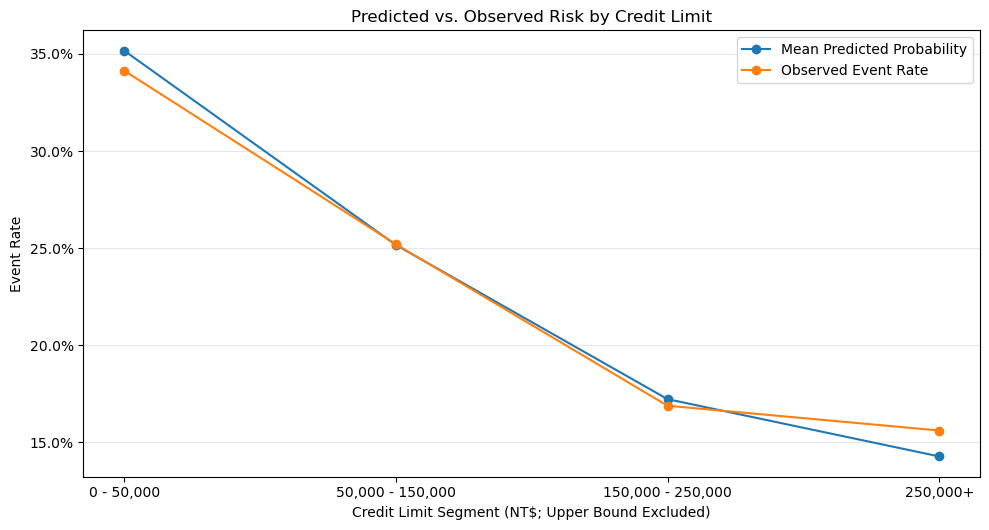

In [151]:
tabla_grafico = tabla_segmentos.set_index("Segmento_Limite")

plt.figure(figsize=(10, 5.4))

plt.plot(
    tabla_grafico.index,
    tabla_grafico["PD_promedio_pct"],
    marker="o",
    label="Mean Predicted Probability"
)

plt.plot(
    tabla_grafico.index,
    tabla_grafico["Tasa_mora_pct"],
    marker="o",
    label="Observed Event Rate"
)

plt.gca().yaxis.set_major_formatter(
    PercentFormatter(xmax=100)
)

plt.title("Predicted vs. Observed Risk by Credit Limit")
plt.xlabel("Credit Limit Segment (NT$; Upper Bound Excluded)")
plt.ylabel("Event Rate")
plt.xticks(rotation=0)
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


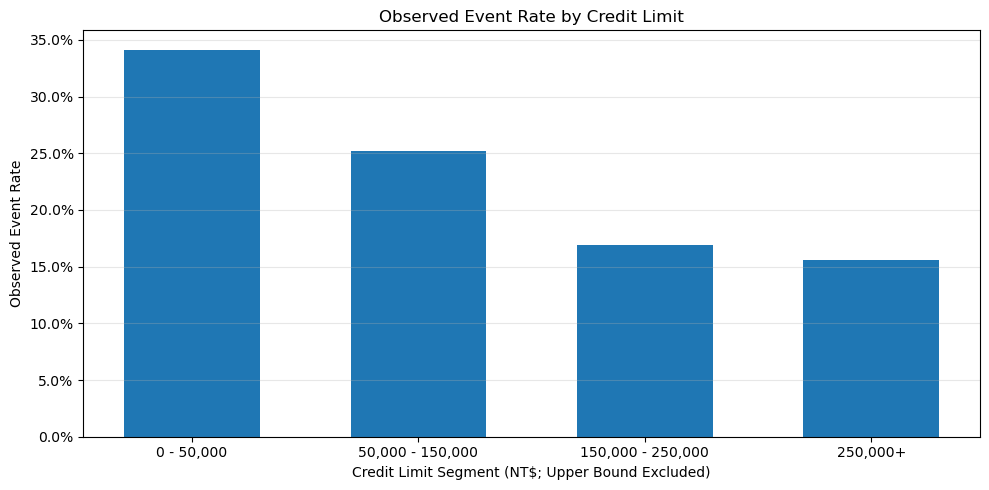

In [152]:
plt.figure(figsize=(10, 5))

plt.bar(
    tabla_segmentos["Segmento_Limite"],
    tabla_segmentos["Tasa_mora_pct"],
    width=0.6
)

# Usa xmax=100 porque Tasa_mora_pct ya está expresada como porcentaje
plt.gca().yaxis.set_major_formatter(
    PercentFormatter(xmax=100)
)

plt.title("Observed Event Rate by Credit Limit")
plt.xlabel("Credit Limit Segment (NT$; Upper Bound Excluded)")
plt.ylabel("Observed Event Rate")
plt.xticks(rotation=0)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Predicted vs. Observed Risk

Comparamos la media y la mediana de las PD y, después, el error promedio por segmento. Las cantidades de clientes permanecen como conteos y las tasas se presentan en porcentaje.

In [153]:
tabla_pd = (
    resultado_segmentos
    .groupby(
        "Segmento_Limite",
        observed=True
    )
    .agg(
        Clientes=("Y_real", "count"),
        PD_media=("PD", "mean"),
        PD_mediana=("PD", "median"),
        Mora_real=("Y_real", "mean")
    )
)

tabla_pd[
    [
        "PD_media",
        "PD_mediana",
        "Mora_real"
    ]
] *= 100

tabla_pd.round(2)


,Clientes,PD_media,PD_mediana,Mora_real
Segmento_Limite,,,,
"0 - 50,000",1283,35.17,25.89,34.14
"50,000 - 150,000",3333,25.17,16.42,25.20
"150,000 - 250,000",2226,17.23,12.17,16.89
"250,000+",2158,14.28,9.69,15.62


In [154]:
calibracion_segmentos = (
    resultado_segmentos
    .groupby(
        "Segmento_Limite",
        observed=True
    )
    .agg(
        Clientes=("Y_real", "count"),
        PD_promedio=("PD", "mean"),
        Mora_observada=("Y_real", "mean")
    )
)

calibracion_segmentos[
    "Error_calibracion_pp"
] = (
    calibracion_segmentos[
        "PD_promedio"
    ]
    -
    calibracion_segmentos[
        "Mora_observada"
    ]
) * 100

calibracion_segmentos[
    "PD_promedio_pct"
] = (
    calibracion_segmentos[
        "PD_promedio"
    ] * 100
)

calibracion_segmentos[
    "Mora_observada_pct"
] = (
    calibracion_segmentos[
        "Mora_observada"
    ] * 100
)

calibracion_segmentos[
    [
        "Clientes",
        "PD_promedio_pct",
        "Mora_observada_pct",
        "Error_calibracion_pp"
    ]
].round(2)


,Clientes,PD_promedio_pct,Mora_observada_pct,Error_calibracion_pp
Segmento_Limite,,,,
"0 - 50,000",1283,35.17,34.14,1.03
"50,000 - 150,000",3333,25.17,25.20,-0.04
"150,000 - 250,000",2226,17.23,16.89,0.34
"250,000+",2158,14.28,15.62,-1.33


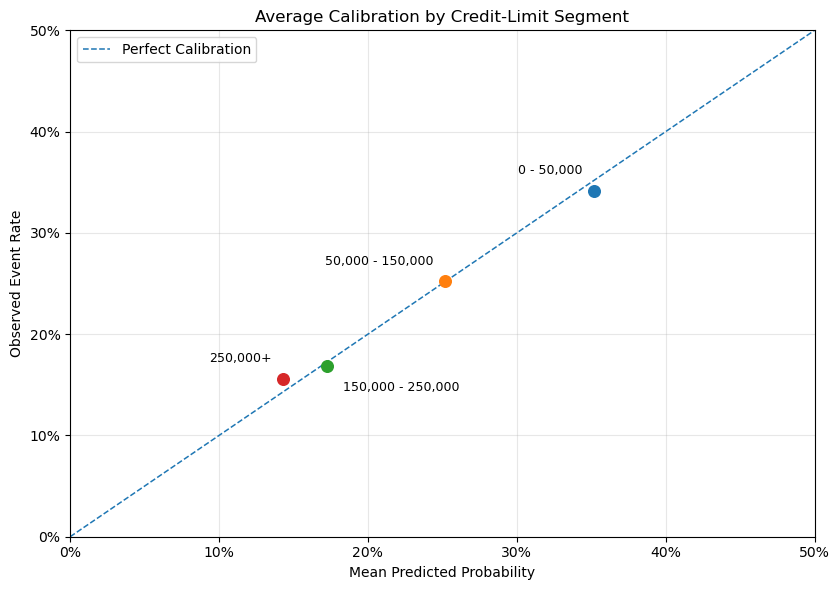

In [155]:
plt.figure(figsize=(8.5, 6))

plt.plot(
    [0, 0.5],
    [0, 0.5],
    linestyle="--",
    linewidth=1.1,
    label="Perfect Calibration"
)

for position, (_, fila) in enumerate(tabla_segmentos.iterrows()):

    plt.scatter(
        fila["PD_promedio"],
        fila["Tasa_mora"],
        s=70,
        zorder=3
    )

    # Se desplaza únicamente la etiqueta, no el punto
    offset = (-8, 12) if position != 2 else (12, -18)

    plt.annotate(
        fila["Segmento_Limite"],
        (fila["PD_promedio"], fila["Tasa_mora"]),
        xytext=offset,
        textcoords="offset points",
        fontsize=9,
        ha="right" if position != 2 else "left"
    )

plt.xlim(0, 0.5)
plt.ylim(0, 0.5)

# Los valores 0–1 se muestran como porcentajes
plt.gca().xaxis.set_major_formatter(
    PercentFormatter(xmax=1)
)
plt.gca().yaxis.set_major_formatter(
    PercentFormatter(xmax=1)
)

plt.title("Average Calibration by Credit-Limit Segment")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Event Rate")
plt.grid(True, axis="both", alpha=0.3)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


In [156]:
resultado_segmentos["Segmento_Limite"].value_counts().sort_index()


Segmento_Limite
0 - 50,000           1283
50,000 - 150,000     3333
150,000 - 250,000    2226
250,000+             2158
Name: count, dtype: int64

### Calibration by Credit-Limit Segment

En una sola figura comparamos la calibración interna de los cuatro segmentos de límite. Esto permite detectar si un segmento presenta desviaciones sistemáticas sin multiplicar gráficas repetitivas.


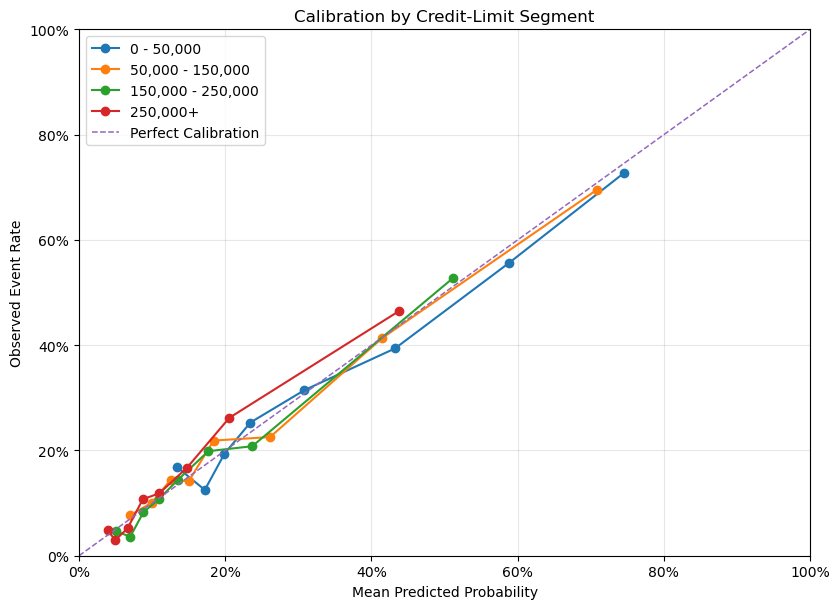

In [157]:
plt.figure(figsize=(8.5, 6.2))

for segmento, grupo in resultado_segmentos.groupby("Segmento_Limite", observed=True):
    if grupo["Y_real"].nunique() < 2 or len(grupo) < 20:
        continue

    prob_real, prob_predicha = calibration_curve(
        grupo["Y_real"],
        grupo["PD"],
        n_bins=8,
        strategy="quantile"
    )

    plt.plot(
        prob_predicha,
        prob_real,
        marker="o",
        label=str(segmento)
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.1,
    label="Perfect Calibration"
)

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().xaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1))

plt.title("Calibration by Credit-Limit Segment")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Event Rate")
plt.grid(True, axis="both", alpha=0.3)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


### A Closer Look at the Lowest-Limit Segment

Las siguientes tablas desglosan el error dentro del primer segmento por grupos de PD, racha de atraso y estado de septiembre. Buscamos dónde se concentra la diferencia entre lo estimado y lo observado.

In [158]:
seg_0_50 = resultado_segmentos[
    resultado_segmentos["Segmento_Limite"] == "0 - 50,000"
].copy()

seg_0_50["Bin_PD"] = pd.qcut(
    seg_0_50["PD"],
    q=8,
    duplicates="drop"
)

tabla_cal_0_50 = (
    seg_0_50
    .groupby("Bin_PD", observed=True)
    .agg(
        Clientes=("Y_real", "count"),
        PD_promedio=("PD", "mean"),
        Mora_observada=("Y_real", "mean")
    )
    .reset_index()
)

tabla_cal_0_50["Error_pp"] = (
    tabla_cal_0_50["PD_promedio"]
    - tabla_cal_0_50["Mora_observada"]
) * 100

tabla_cal_0_50[
    ["Clientes", "PD_promedio", "Mora_observada", "Error_pp"]
].round(4)


,Clientes,PD_promedio,Mora_observada,Error_pp
0,161,0.1346,0.1677,-3.3114
1,160,0.1720,0.1250,4.7034
2,160,0.1989,0.1938,0.5171
3,162,0.2344,0.2531,-1.8680
4,159,0.3082,0.3145,-0.6289
5,160,0.4322,0.3938,3.8416
6,160,0.5882,0.5562,3.1931
7,161,0.7450,0.7267,1.8286


In [159]:
tabla_subsegmentos = (
    seg_0_50
    .groupby(
        ["racha_max_atraso"],
        observed=True
    )
    .agg(
        Clientes=("Y_real", "count"),
        PD_promedio=("PD", "mean"),
        Mora_observada=("Y_real", "mean")
    )
    .reset_index()
)

tabla_subsegmentos["Error_pp"] = (
    tabla_subsegmentos["PD_promedio"]
    - tabla_subsegmentos["Mora_observada"]
) * 100

tabla_subsegmentos.round(4)


,racha_max_atraso,Clientes,PD_promedio,Mora_observada,Error_pp
0,0,585,0.1828,0.1726,1.0131
1,1,239,0.3563,0.3724,-1.6056
2,2,154,0.4715,0.4610,1.0420
3,3,87,0.5462,0.5057,4.0455
4,4,66,0.5320,0.5000,3.2031
5,5,36,0.6089,0.4444,16.4497
6,6,116,0.7064,0.7241,-1.7712


In [160]:
tabla_x6 = (
    seg_0_50
    .groupby("X6", observed=True)
    .agg(
        Clientes=("Y_real", "count"),
        PD_promedio=("PD", "mean"),
        Mora_observada=("Y_real", "mean")
    )
    .reset_index()
)

tabla_x6["Error_pp"] = (
    tabla_x6["PD_promedio"]
    - tabla_x6["Mora_observada"]
) * 100

tabla_x6.round(4)


,X6,Clientes,PD_promedio,Mora_observada,Error_pp
0,-2,26,0.1551,0.0769,7.8222
1,-1,139,0.2534,0.2302,2.3136
2,0,656,0.2190,0.2241,-0.5125
3,1,203,0.4312,0.3990,3.2149
4,2,195,0.6937,0.6667,2.7069
5,3,41,0.7379,0.7805,-4.2596
6,4,13,0.7114,0.6923,1.9126
7,5,7,0.6181,0.5714,4.6705
8,6,1,0.5771,0.0000,57.7080
9,8,2,0.5480,0.5000,4.8024


## 10. Illustrative PD-to-Score Transformation



In [161]:
# Parámetros ilustrativos de score
base_score = 600
pdo = 50
base_odds = 20

factor = pdo / np.log(2)
offset = base_score - factor * np.log(base_odds)

pd_score = resultado_segmentos["PD"].clip(1e-8, 1 - 1e-8)

resultado_segmentos["Score"] = (
    offset
    + factor * np.log((1 - pd_score) / pd_score)
)

resultado_segmentos[["PD", "Score"]].head()


,PD,Score
8941,0.047996,599.403269
17618,0.445862,399.586033
27895,0.089789,550.983345
16103,0.621333,348.181657
4422,0.070854,569.552282


### Score by Credit-Limit Segment

Este resumen es únicamente una traducción de las PD del modelo.


In [162]:
score_segmentos = (
    resultado_segmentos
    .groupby(
        "Segmento_Limite",
        observed=True
    )
    .agg(
        Clientes=("Y_real", "count"),
        Score_promedio=("Score", "mean"),
        Score_mediano=("Score", "median"),
        PD_promedio=("PD", "mean"),
        Mora_observada=("Y_real", "mean")
    )
    .reset_index()
)

score_segmentos["PD_promedio_pct"] = (
    score_segmentos["PD_promedio"] * 100
)

score_segmentos["Mora_observada_pct"] = (
    score_segmentos["Mora_observada"] * 100
)

score_segmentos[
    [
        "Segmento_Limite",
        "Clientes",
        "Score_promedio",
        "Score_mediano",
        "PD_promedio_pct",
        "Mora_observada_pct"
    ]
].round(2)


,Segmento_Limite,Clientes,Score_promedio,Score_mediano,PD_promedio_pct,Mora_observada_pct
0,"0 - 50,000",1283,435.02,459.76,35.17,34.14
1,"50,000 - 150,000",3333,478.35,501.28,25.17,25.20
2,"150,000 - 250,000",2226,514.44,526.47,17.23,16.89
3,"250,000+",2158,533.90,544.90,14.28,15.62
